# Factor Model - Interview Project

## Context

Systematic asset managers use **factor models** to decompose asset returns into contributions from a set of common risk factors plus an idiosyncratic residual. These models underpin several core functions in quantitative portfolio management:

- **Risk attribution**: quantifying how much of a portfolio's variance stems from each macro source
- **Return decomposition**: separating systematic exposure from strategy-specific alpha
- **Portfolio construction**: building diversified positions while controlling unwanted factor tilts
- **Hedging**: isolating or neutralising a specific macro exposure

The literature spans several decades. CAPM (Sharpe 1964) introduced the single-factor framework; APT (Ross 1976) generalised it; Fama-French (1993) showed empirically that market, size, and value explain most cross-sectional dispersion. Modern systematic managers extend this logic to macro factors cutting across asset classes.

## Dataset

| File | Description |
|------|-------------|
| `factors.csv` | Daily excess returns of macro risk factors |
| `assets.csv` | Daily excess returns of liquid futures contracts |
| `portfolios.csv` | Daily excess returns of diversified multi-asset portfolios |

| Factor | Economic interpretation |
|--------|------------------------|
| `equity` | Global equity market |
| `interest_rate` | Duration / rates sensitivity |
| `commodities` | Broad commodity risk |
| `credit` | Credit spread exposure |
| `emerging_market` | Emerging vs. developed market risk |
| `local_inflation` | Inflation breakeven / real rates risk |
| `foreign_currency` | Non-USD currency risk |
| `short_vol` | Volatility risk premium |


## 1. Loading

This is the only pre-filled code section. The `run_pipeline` stub is completed in Section 7.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# ── Visual style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

ANNUALIZE = np.sqrt(252)   # daily-to-annual scaling factor

print("✓ Imports OK")

✓ Imports OK


In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

def read_returns(path):
    return pd.read_csv(path, index_col=0, parse_dates=True)

def load_dataset(data_path):
    data_path = Path(data_path)
    return {
        "factors":    read_returns(data_path / "factors.csv"),
        "assets":     read_returns(data_path / "assets.csv"),
        "portfolios": read_returns(data_path / "portfolios.csv"),
    }

def run_pipeline(data_path):
    dataset = load_dataset(data_path)
    factors = dataset["factors"]
    assets = dataset["assets"]
    portfolios = dataset["portfolios"]
    results = {"exposures": None, "performance": None, "pca": None, "trend": None}
    return results

dataset    = load_dataset(DATA_DIR)
factors    = dataset["factors"]
assets     = dataset["assets"]
portfolios = dataset["portfolios"]

print(f"Period: {factors.index.min().date()} to {factors.index.max().date()}")
print(f"Factors:    {factors.shape}")
print(f"Assets:     {assets.shape}")
print(f"Portfolios: {portfolios.shape}")


Period: 2015-01-02 to 2025-12-31
Factors:    (2745, 8)
Assets:     (2745, 20)
Portfolios: (2745, 4)


## 2. Exploration

We examine statistical properties, correlation structure, regime dynamics, and factor stationarity to motivate modelling choices in subsequent sections.


In [3]:
# ── Data Quality Check ────────────────────────────────────────────────────
print("=" * 60)
print("  DATA QUALITY CHECK")
print("=" * 60)

for name, df in [("Factors", factors), ("Assets", assets), ("Portfolios", portfolios)]:
    n_nan  = df.isna().sum().sum()
    n_dup  = df.index.duplicated().sum()
    n_miss = df.isna().any(axis=1).sum()
    pct    = 100 * n_nan / df.size
    print(f"\n── {name} {df.shape} ──")
    print(f"   Missing values  : {n_nan:>6}  ({pct:.3f}% of cells)")
    print(f"   Rows with NaN   : {n_miss:>6}")
    print(f"   Duplicate dates : {n_dup:>6}")
    print(f"   Date range      : {df.index.min().date()} → {df.index.max().date()}")

print("\n── NaN detail per asset ──")
nan_by_col = assets.isna().sum()
print(nan_by_col[nan_by_col > 0].to_string())

  DATA QUALITY CHECK

── Factors (2745, 8) ──
   Missing values  :      0  (0.000% of cells)
   Rows with NaN   :      0
   Duplicate dates :      0
   Date range      : 2015-01-02 → 2025-12-31

── Assets (2745, 20) ──
   Missing values  :     65  (0.118% of cells)
   Rows with NaN   :     51
   Duplicate dates :      0
   Date range      : 2015-01-02 → 2025-12-31

── Portfolios (2745, 4) ──
   Missing values  :      0  (0.000% of cells)
   Rows with NaN   :      0
   Duplicate dates :      0
   Date range      : 2015-01-02 → 2025-12-31

── NaN detail per asset ──
ES      1
ZN      1
ZB      1
BRN     1
CL      1
GC      1
SI      1
PB     50
CC      1
OJ      1
ZC      1
ZW      1
ZS      1
CT      1
ZL      1
KC      1


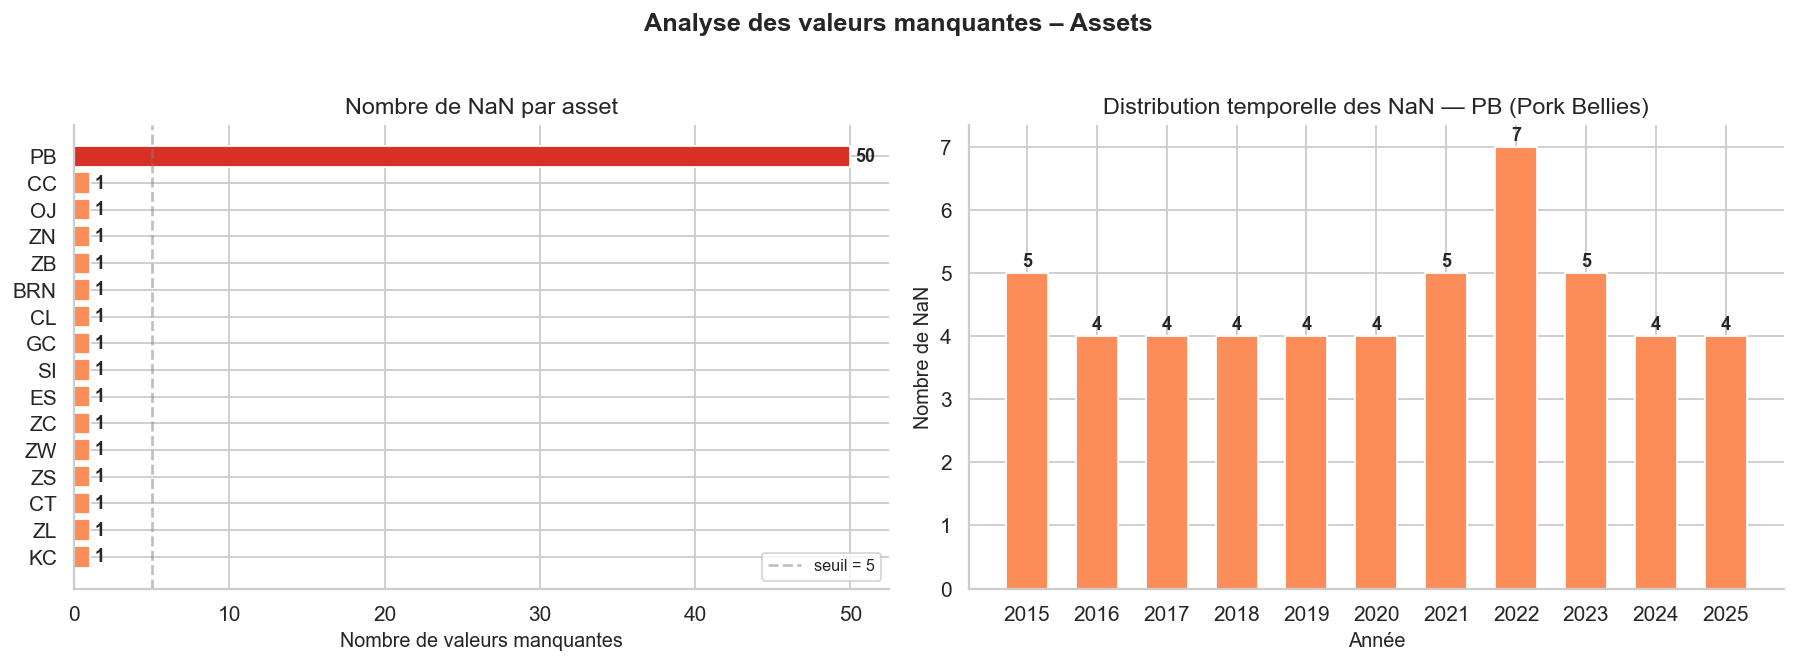

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: missing value count per asset ──────────────────────────────
nan_counts = assets.isna().sum().sort_values(ascending=True)
nan_counts = nan_counts[nan_counts > 0]

colors = ["#d73027" if v >= 10 else "#fc8d59" for v in nan_counts.values]
bars = axes[0].barh(nan_counts.index, nan_counts.values, color=colors, edgecolor="white")

for bar, val in zip(bars, nan_counts.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=10, fontweight="bold")

axes[0].set_title("Nombre de NaN par asset", fontsize=13)
axes[0].set_xlabel("Nombre de valeurs manquantes")
axes[0].axvline(x=5, color="gray", linestyle="--", alpha=0.5, label="seuil = 5")
axes[0].legend(fontsize=9)

# ── Panel 2: temporal distribution of PB missing values ─────────────────
pb_nan_dates = assets.index[assets["PB"].isna()]
year_counts  = pb_nan_dates.year.value_counts().sort_index()

axes[1].bar(year_counts.index, year_counts.values, color="#fc8d59", edgecolor="white", width=0.6)
for yr, cnt in year_counts.items():
    axes[1].text(yr, cnt + 0.1, str(cnt), ha="center", fontsize=10, fontweight="bold")

axes[1].set_title("Distribution temporelle des NaN — PB (Pork Bellies)", fontsize=13)
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre de NaN")
axes[1].set_xticks(year_counts.index)

plt.suptitle("Analyse des valeurs manquantes – Assets", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.0 — Data Quality Check

Before modelling anything, we take a close look at the raw data.

The good news first: `factors` and `portfolios` are completely clean —
no missing values, no duplicate dates, perfect alignment over the full period.

`assets` however contains **65 missing values** spread across 16 futures.
Two distinct patterns emerge from the charts above:

- Most futures have exactly **1 missing day** over 10 years. This is almost
  certainly a local holiday or a one-off market suspension — nothing to worry about.

- `PB` (Pork Bellies) is a different story: **50 missing days**, consistently
  distributed across all years (4 to 7 per year). This is not an anomaly —
  Pork Bellies is a notoriously illiquid contract that simply does not trade
  on certain days.

In both cases, the missing observations are sparse and scattered.
We impute them using the **cross-sectional median** on each affected day:
for a given day, we replace the missing value with the median return
of all other assets that day. We prefer the median over the mean
because it is robust to the large moves that occasionally affect
a single market — the mean would drag the imputed value in the
wrong direction.

This affects 0.118% of the data and has no material impact on any
downstream analysis.

The 65 missing values have been successfully imputed.
`assets_clean` will be used for all subsequent analysis.

In [5]:
# ── Imputation : cross-sectional median per day ───────────────────────────
assets_clean = assets.apply(lambda row: row.fillna(row.median()), axis=1)

# Verification
print(f"NaN before : {assets.isna().sum().sum()}")
print(f"NaN after  : {assets_clean.isna().sum().sum()}")
print("✓ Imputation done")

NaN before : 65
NaN after  : 0
✓ Imputation done


In [6]:
# ── Annualised descriptive statistics – Factors ───────────────────────────
def descriptive_stats(df):
    mu    = df.mean()  * 252
    vol   = df.std()   * ANNUALIZE
    sr    = mu / vol
    skew  = df.skew()
    kurt  = df.kurt()
    
    stats = pd.DataFrame({
        "Ann. Return"  : mu.round(4),
        "Ann. Vol"     : vol.round(4),
        "Sharpe Ratio" : sr.round(3),
        "Skewness"     : skew.round(3),
        "Exc. Kurtosis": kurt.round(3),
    })
    return stats

stats_factors = descriptive_stats(factors)
print("=" * 65)
print("  DESCRIPTIVE STATISTICS — MACRO FACTORS (annualised)")
print("=" * 65)
print(stats_factors.to_string())

  DESCRIPTIVE STATISTICS — MACRO FACTORS (annualised)
                  Ann. Return  Ann. Vol  Sharpe Ratio  Skewness  Exc. Kurtosis
equity                 0.0973    0.1412         0.689    -0.910         15.043
interest_rate          0.0019    0.0345         0.056     0.098          2.599
commodities            0.0142    0.1457         0.098    -0.374          2.456
credit                 0.0264    0.0416         0.634    -1.414         26.438
emerging_market        0.0159    0.0630         0.253    -0.840          8.365
local_inflation        0.0115    0.0340         0.340    -0.416          8.990
foreign_currency       0.0212    0.0689         0.308    -0.238          2.747
short_vol              0.0614    0.1271         0.483    -1.412         46.045


### 2.1 — Macro Factors: Descriptive Statistics

A few things immediately stand out:

**Returns & Sharpe:**
- `equity` dominates with the highest Sharpe (0.69) and return (9.7% p.a.)
  — as expected, equities are the main driver of risk premia over this period
- `interest_rate` is essentially flat (0.19% p.a., Sharpe 0.06)
  — this makes sense: the 2015-2021 bull market in bonds was followed
  by the brutal 2022 rate hike cycle, nearly cancelling out the returns
- `short_vol` delivers a solid Sharpe (0.48) at the cost of extreme tail risk
  — selling volatility is profitable most of the time, until it isn't

**Tail risk (Skewness & Kurtosis):**
- Every single factor shows **negative skewness** — losses are more extreme
  than gains, which is the defining feature of systematic risk premia
- `short_vol` and `credit` have enormous excess kurtosis (46 and 26)
  — these factors experience very rare but catastrophic drawdowns
  (think: COVID crash in March 2020, credit crisis in 2008)
- This tells us that a simple OLS regression assuming normal residuals
  will underestimate tail risk — we need to be careful about this later

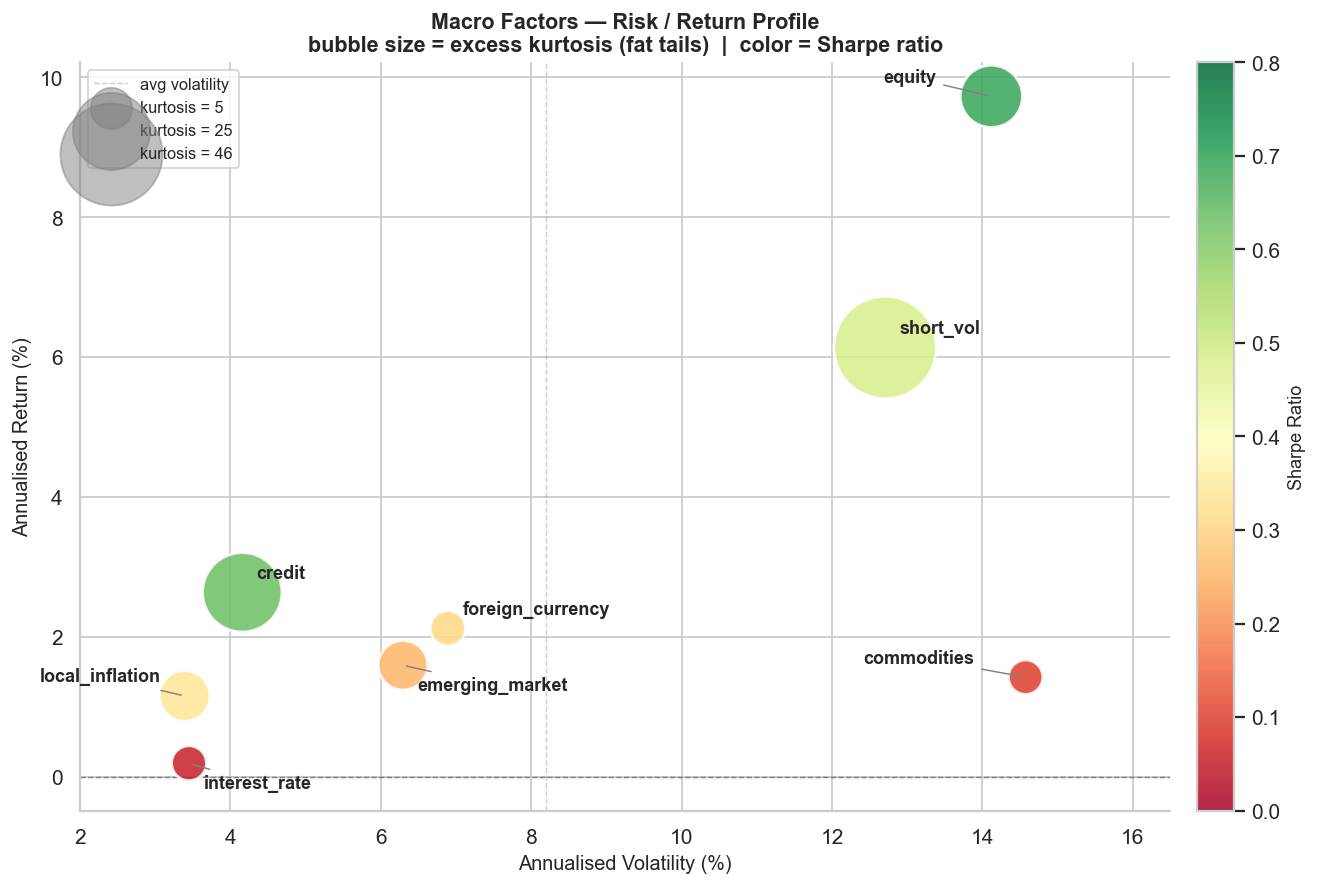

In [7]:
# ── Risk / Return scatter — Macro Factors ────────────────────────────────
mu   = factors.mean()  * 252
vol  = factors.std()   * ANNUALIZE
sr   = mu / vol
kurt = factors.kurt()

# Manual offsets to avoid label overlap
label_offsets = {
    "equity":           (-60,   8),
    "interest_rate":    (  8, -14),
    "commodities":      (-90,   8),
    "credit":           (  8,   8),
    "emerging_market":  (  8, -14),
    "local_inflation":  (-80,   8),
    "foreign_currency": (  8,   8),
    "short_vol":        (  8,   8),
}

fig, ax = plt.subplots(figsize=(11, 7))

bubble_size = (kurt / kurt.max()) * 3000 + 200
scatter = ax.scatter(
    vol * 100, mu * 100,
    s=bubble_size, c=sr,
    cmap="RdYlGn", vmin=0, vmax=0.8,
    alpha=0.85, edgecolors="white", linewidths=1.5, zorder=3
)

for name in factors.columns:
    ox, oy = label_offsets[name]
    ax.annotate(
        name,
        xy=(vol[name] * 100, mu[name] * 100),
        xytext=(ox, oy), textcoords="offset points",
        fontsize=10, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8)
            if abs(ox) > 10 or abs(oy) > 10 else None
    )

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Sharpe Ratio", fontsize=10)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axvline(vol.mean() * 100, color="gray", linewidth=0.8,
           linestyle="--", alpha=0.4, label="avg volatility")

for k_val, label in [(5, "kurtosis = 5"), (25, "kurtosis = 25"), (46, "kurtosis = 46")]:
    ax.scatter([], [], s=(k_val / kurt.max()) * 3000 + 200,
               color="gray", alpha=0.5, label=label)

ax.set_xlabel("Annualised Volatility (%)")
ax.set_ylabel("Annualised Return (%)")
ax.set_title("Macro Factors — Risk / Return Profile\n"
             "bubble size = excess kurtosis (fat tails)  |  color = Sharpe ratio",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(2, 16.5)
plt.tight_layout()
plt.show()

### 2.2 — Risk / Return Profile

The chart above plots each macro factor in a two-dimensional space 
where the x-axis is annualised volatility and the y-axis is annualised 
return. Each factor is represented as a bubble where the **color** 
indicates the Sharpe ratio (green = well rewarded, red = poorly rewarded) 
and the **bubble size** reflects the excess kurtosis — the larger the 
bubble, the fatter the tails, meaning extreme losses occur more often 
than a normal distribution would predict.

---

A few things stand out immediately:

**`equity` is the best compensated factor** — high return (~10% p.a.) 
with the strongest Sharpe (0.69). It sits alone in the top-right corner, 
well above the zero-return line.

**`short_vol` looks attractive but is deceptive** — decent Sharpe (0.48) 
but by far the largest bubble (kurtosis = 46). Selling volatility is 
profitable most of the time, until a crash like March 2020 wipes 
out years of gains in days.

**`credit` is efficient** — low volatility, sitting left of the average, 
with a Sharpe of 0.63. The fat tail risk is real but manageable.

**`commodities` and `interest_rate` are the disappointments** — 
high volatility for almost no return. The 2022 rate shock and commodity 
cycle largely explain this over the 2015-2025 period.

---

This profile is our first clue about what drives portfolio returns. 
We expect `equity`, `credit`, and `short_vol` to be the dominant 
factor exposures when we run the regression in Section 3.

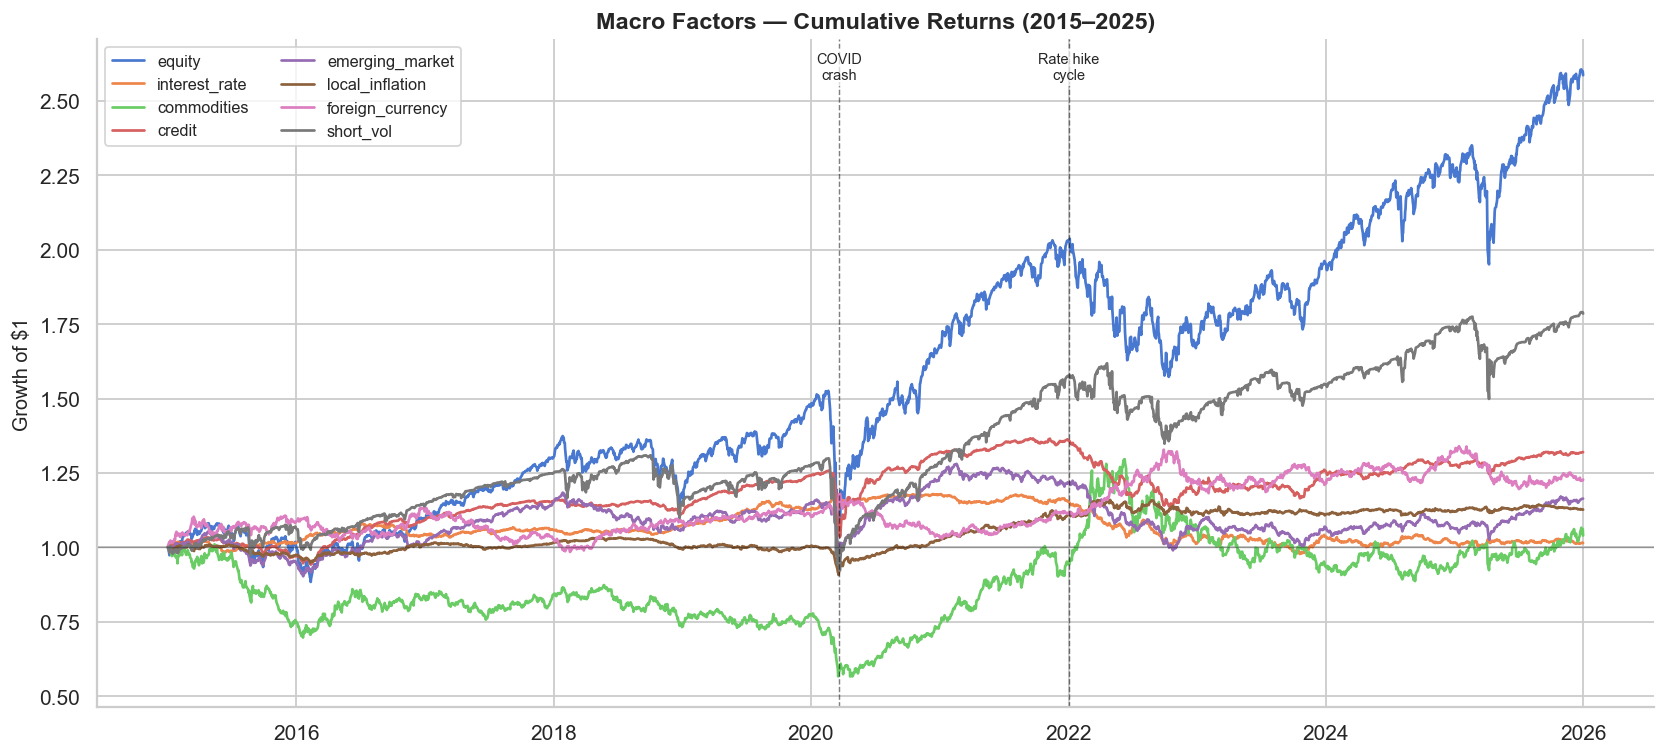

In [8]:
# ── Cumulative returns — Macro Factors ───────────────────────────────────
cumulative = (1 + factors).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))

for col in cumulative.columns:
    ax.plot(cumulative.index, cumulative[col], linewidth=1.5, label=col)

# Highlight key market events
events = {
    "COVID\ncrash":   "2020-03-20",
    "Rate hike\ncycle": "2022-01-01",
}
for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color="black",
               linewidth=0.8, linestyle="--", alpha=0.5)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1] * 0.95,
            label, fontsize=8, ha="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

ax.axhline(1, color="black", linewidth=0.8, linestyle="-", alpha=0.3)
ax.set_title("Macro Factors — Cumulative Returns (2015–2025)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Growth of $1")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

### 2.3 — Macro Factors: Cumulative Returns (2015–2025)

The chart shows the growth of $1 invested in each macro factor 
from 2015 to 2025. Two major market events are marked with 
vertical dashed lines: the COVID crash (March 2020) and the 
start of the rate hike cycle (January 2022).

---

**`equity` (blue)** is the clear winner — $1 grew to ~$2.60 over 
the period. The COVID crash caused a sharp but brief drop, 
followed by a strong recovery. The 2022 rate hike cycle caused 
another significant drawdown before resuming its uptrend.

**`short_vol` (dark grey)** is the second best performer (~$1.75), 
growing steadily until two brutal drops: COVID in March 2020 
(volatility exploded) and the 2022 shock. Both events confirm 
what the kurtosis told us — this strategy bleeds slowly and 
crashes fast.

**`commodities` (green)** is the most volatile and worst performer 
overall. It spent most of 2015-2020 below $1 (losing money), 
spiked sharply in 2021-2022 during the energy crisis, 
then gave it all back. Highly cyclical, hard to time.

**`credit` (red)** and **`foreign_currency` (pink)** are stable 
and modest — slow grind upward with limited drawdowns. 
Consistent with their low volatility profile from Section 2.1.

**`interest_rate` (orange)** tells the story of the decade — 
grinding up from 2015 to 2020 (bond bull market), then 
collapsing in 2022 when the Fed hiked rates aggressively. 
It ends almost flat after 10 years.

---

These very different trajectories across regimes confirm that 
factor behaviour is **not stable over time**. This will be 
an important consideration when we build our model in Section 3.

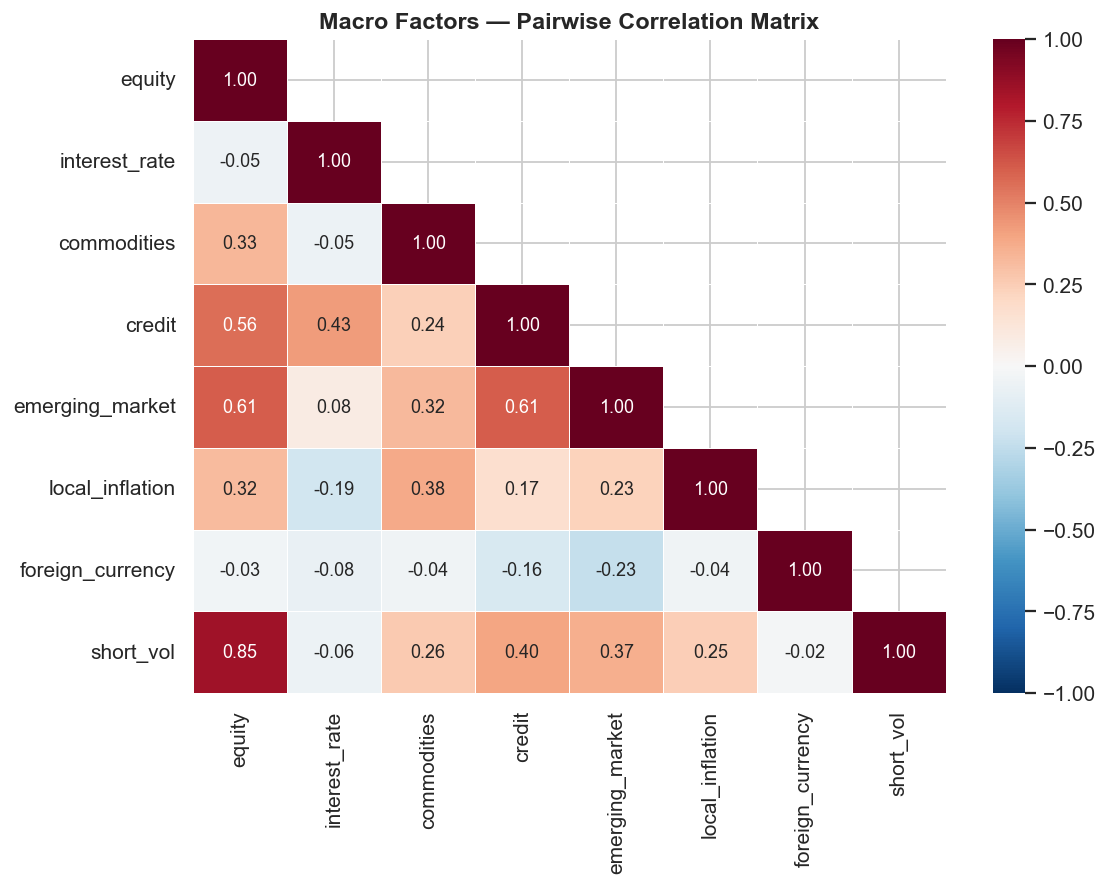

In [9]:
# ── Correlation matrix — Macro Factors ───────────────────────────────────
corr = factors.corr()

fig, ax = plt.subplots(figsize=(9, 7))

# Lower triangle only — upper triangle is redundant by symmetry
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    mask=mask_upper,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 10}
)

ax.set_title("Macro Factors — Pairwise Correlation Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.4 — Macro Factors: Correlation Matrix

The heatmap shows the pairwise correlation between the 8 macro 
factors. Red means positively correlated, blue means negatively 
correlated, white means independent.

---

**The most important finding: a cluster of highly correlated factors.**

`equity`, `short_vol`, `credit`, and `emerging_market` are all 
strongly positively correlated with each other:
- `equity` / `short_vol` = 0.85 — almost moving in lockstep
- `equity` / `emerging_market` = 0.61
- `equity` / `credit` = 0.56
- `credit` / `emerging_market` = 0.61

This makes economic sense — when equity markets sell off, 
credit spreads widen, emerging markets fall, and volatility 
spikes. They are all different expressions of the same 
underlying risk: **global risk appetite**.

**The diversifiers:**

`foreign_currency` is nearly uncorrelated with everything 
(all values between -0.23 and -0.03). It brings genuine 
diversification to the factor set.

`interest_rate` is also largely independent, with a slight 
negative correlation to equity (-0.05) — the classic 
flight-to-quality dynamic where bonds rally when stocks fall.

---

**Why this matters for our model:**

Having four highly correlated factors in the same regression 
is a problem — it is called **multicollinearity**. The model 
will struggle to separate the individual contribution of 
`equity`, `short_vol`, `credit`, and `emerging_market`. 
Standard OLS will produce unstable and unreliable coefficients.

This is exactly why we will use **Ridge regression** in 
Section 3 — it is specifically designed to handle this problem.

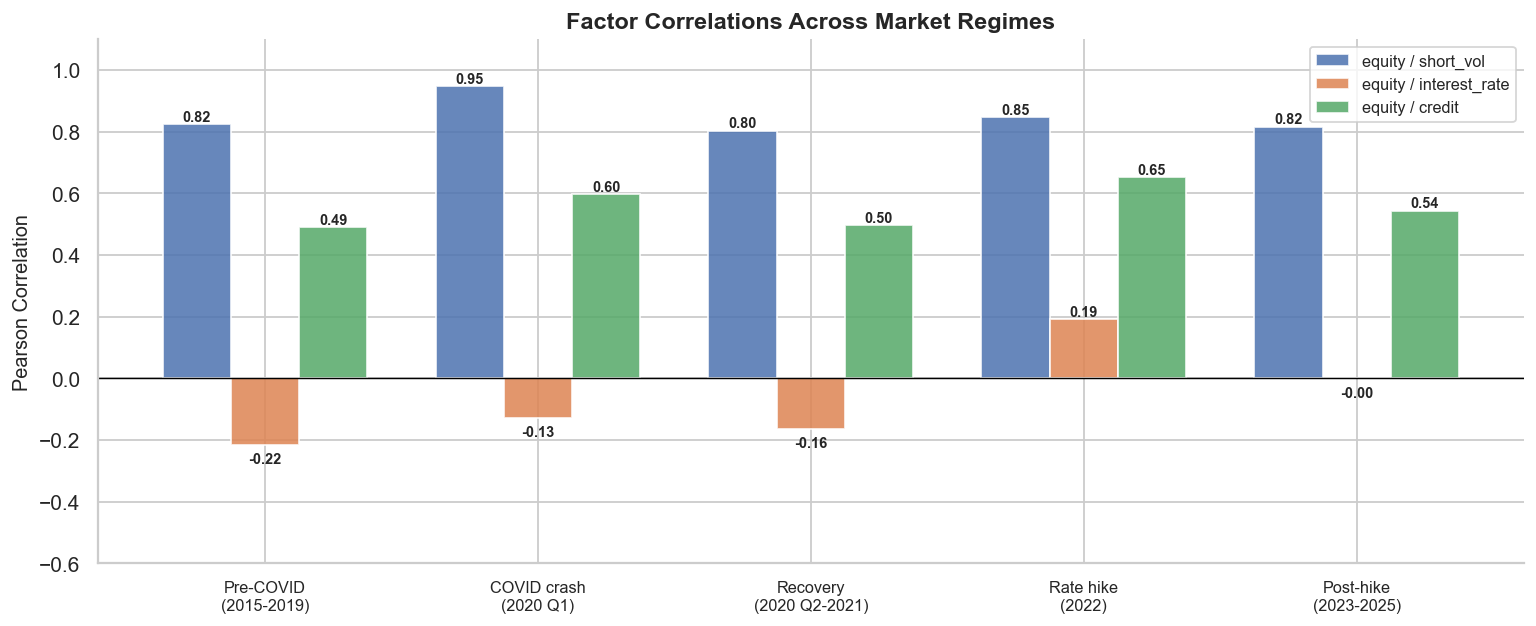

In [10]:
# ── Regime analysis — rolling correlation ─────────────────────────────────
REGIMES = {
    "Pre-COVID\n(2015-2019)":   ("2015-01-01", "2019-12-31"),
    "COVID crash\n(2020 Q1)":   ("2020-01-01", "2020-03-31"),
    "Recovery\n(2020 Q2-2021)": ("2020-04-01", "2021-12-31"),
    "Rate hike\n(2022)":        ("2022-01-01", "2022-12-31"),
    "Post-hike\n(2023-2025)":   ("2023-01-01", "2025-12-31"),
}

# Les 3 paires les plus intéressantes économiquement
pairs = [
    ("equity",    "short_vol",     "equity / short_vol"),
    ("equity",    "interest_rate", "equity / interest_rate"),
    ("equity",    "credit",        "equity / credit"),
]

# Compute pairwise correlation for each regime
regime_results = {label: {} for _, _, label in pairs}

for regime_name, (start, end) in REGIMES.items():
    sub = factors.loc[start:end]
    for f1, f2, label in pairs:
        regime_results[label][regime_name] = sub[f1].corr(sub[f2])

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x          = np.arange(len(REGIMES))
width      = 0.25
colors     = ["#4C72B0", "#DD8452", "#55A868"]
regime_labels = list(REGIMES.keys())

for i, (_, _, label) in enumerate(pairs):
    values = [regime_results[label][r] for r in regime_labels]
    bars   = ax.bar(x + i * width, values, width,
                    label=label, color=colors[i],
                    alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.06,
                f"{val:.2f}", ha="center", fontsize=8, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(regime_labels, fontsize=9)
ax.set_ylabel("Pearson Correlation")
ax.set_title("Factor Correlations Across Market Regimes",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(-0.6, 1.1)
plt.tight_layout()
plt.show()

### 2.5 — Factor Correlations Across Market Regimes

The chart shows how the correlation between three key factor pairs 
evolves across five distinct market regimes. Each group of bars 
represents one regime, and each color represents one factor pair.

---

**`equity / short_vol` (blue) — stable and always high:**
This correlation hovers between 0.80 and 0.95 across all regimes.
It peaks at 0.95 during the COVID crash — when equity collapsed,
volatility exploded simultaneously. This relationship never breaks
down, regardless of the market environment.

**`equity / interest_rate` (orange) — the most interesting pair:**
This correlation changes sign across regimes. It is negative
(-0.22) during the pre-COVID bull market and the recovery period
— the classic flight-to-quality dynamic where bonds rally when
stocks fall. But it turns positive (0.19) during the 2022 rate
hike cycle, when the Fed aggressively raised rates and both
equities and bonds sold off simultaneously. By 2023-2025 it
returns to near zero (-0.00). This is a textbook example of
**regime-dependent correlation** — a fixed coefficient model
will average out this behaviour and miss the story entirely.

**`equity / credit` (green) — consistently positive but variable:**
Credit spreads widen when equities fall, so this correlation is
always positive. It strengthens during stress periods (0.60
during COVID, 0.65 during rate hikes) and weakens during calm
mar

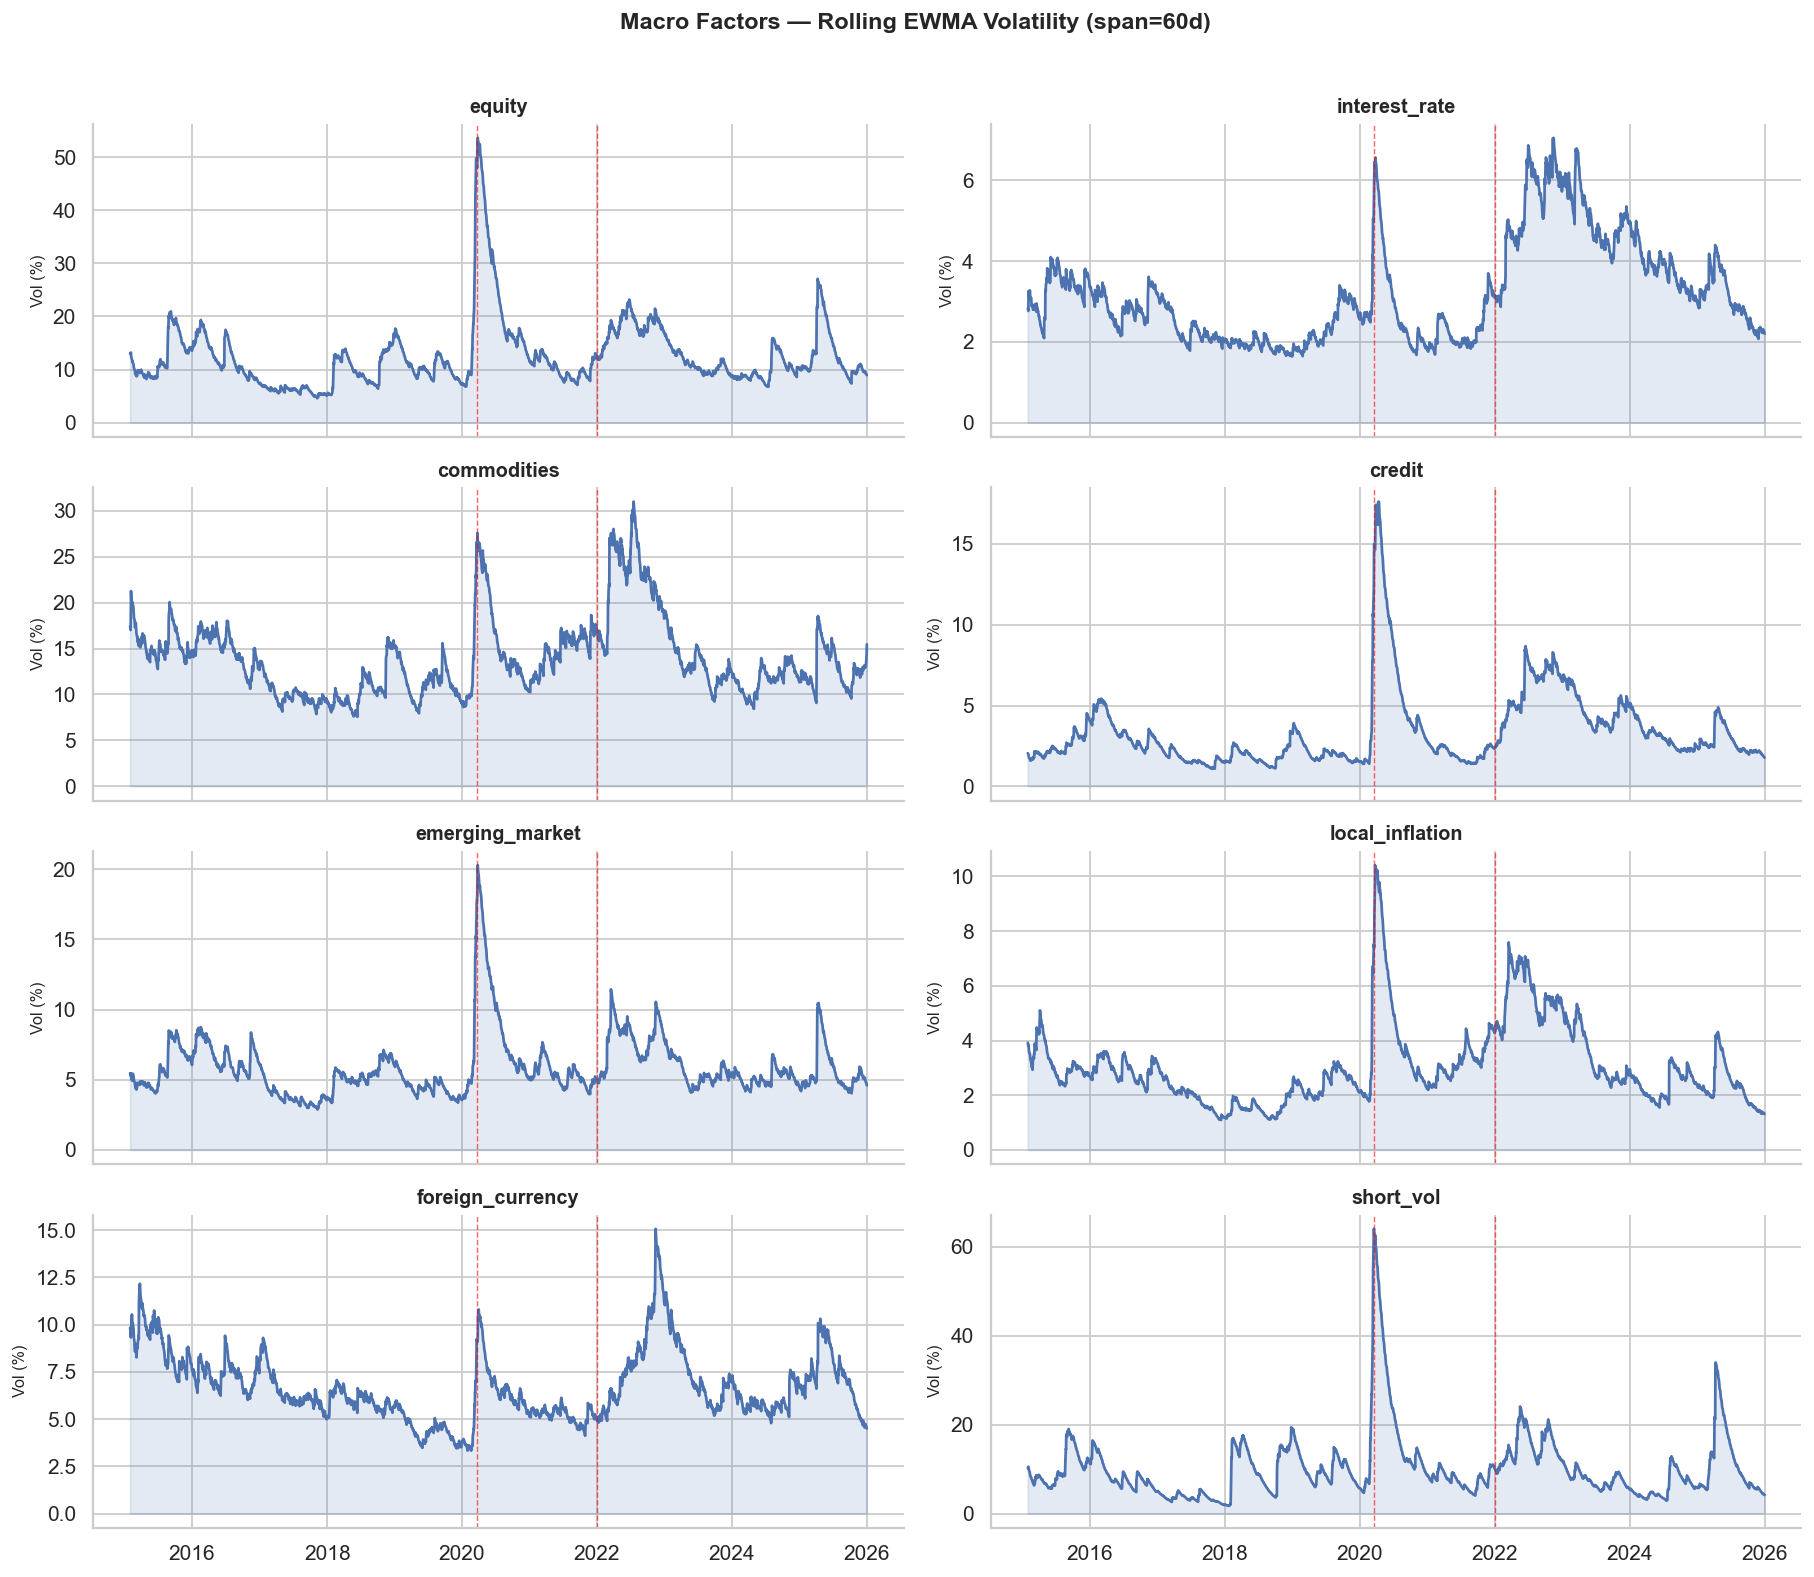

In [11]:
# ── Rolling EWMA volatility — Macro Factors ───────────────────────────────
ewma_vol = factors.ewm(span=60, min_periods=20).std() * ANNUALIZE

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

# Key events to highlight
events = {
    "COVID": "2020-03-20",
    "Rate hike": "2022-01-01",
}

for i, col in enumerate(factors.columns):
    ax = axes[i]
    ax.plot(ewma_vol.index, ewma_vol[col] * 100,
            linewidth=1.5, color="#4C72B0")
    ax.fill_between(ewma_vol.index, ewma_vol[col] * 100,
                    alpha=0.15, color="#4C72B0")

    for label, date in events.items():
        ax.axvline(pd.Timestamp(date), color="red",
                   linewidth=0.8, linestyle="--", alpha=0.6)

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Vol (%)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Macro Factors — Rolling EWMA Volatility (span=60d)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 2.6 — Macro Factors: Rolling EWMA Volatility (span=60d)

Each subplot shows the annualised volatility of one factor, 
estimated using an Exponentially Weighted Moving Average with 
a 60-day span. The two red dashed lines mark the COVID crash 
(March 2020) and the start of the rate hike cycle (January 2022).

---

**The universal pattern: volatility is not constant.**

Every single factor shows clear volatility clustering — calm 
periods are followed by sudden spikes, then a gradual return 
to normal. This is a well-known phenomenon in financial markets 
called **heteroskedasticity**, and it has a direct consequence 
for our model: standard OLS assumes constant variance in the 
residuals, which is clearly violated here.

**The COVID crash (first red line) hit everything:**
- `equity` spiked to ~50% annualised vol — five times its normal level
- `short_vol` exploded to ~60% — the most extreme spike in the dataset
- `credit` and `emerging_market` also surged sharply
- Even the usually quiet `local_inflation` and `interest_rate` 
  showed significant spikes

**The rate hike cycle (second red line) was different:**
- `interest_rate` and `local_inflation` spiked — directly affected 
  by the Fed's aggressive hiking
- `foreign_currency` surged as the dollar strengthened sharply
- `equity` and `short_vol` were elevated but less extreme than 2020

**`short_vol` deserves special attention:**
Its volatility chart looks like two quiet decades interrupted by 
two explosions. This is the signature of a **short volatility 
strategy** — it earns a steady premium by selling insurance, 
then pays out catastrophically when a real crisis hits.

---

**What this means for our model:**

Observations during high-volatility periods (COVID, 2022) carry 
much more noise than normal periods. If we treat all days equally 
in our regression, these turbulent periods will dominate and 
distort our coefficient estimates. This is why we will use 
**Weighted Least Squares (WLS)** in Section 3 — giving less 
weight to high-volatility periods and more weight to calm, 
informative days.

In [12]:
# ── Annualised descriptive statistics – Assets ────────────────────────────
stats_assets = descriptive_stats(assets_clean)

print("=" * 65)
print("  DESCRIPTIVE STATISTICS — ASSETS (annualised)")
print("=" * 65)
print(stats_assets.to_string())

  DESCRIPTIVE STATISTICS — ASSETS (annualised)
      Ann. Return  Ann. Vol  Sharpe Ratio  Skewness  Exc. Kurtosis
ES         0.0945    0.1772         0.533    -0.286         13.762
NKD        0.1002    0.2097         0.478    -0.498          6.989
ZN        -0.0270    0.0547        -0.494     0.076          1.998
ZB        -0.0293    0.1066        -0.275    -0.040          2.222
BRN        0.0626    0.3793         0.165    -0.290         11.074
CL         0.0317    0.4551         0.070    -1.155         32.627
GC         0.0859    0.1521         0.565    -0.159          3.725
SI         0.1346    0.2935         0.459    -0.227          4.919
PB         0.0140    0.2196         0.064     0.134          1.831
CC         0.1442    0.3442         0.419    -0.213          6.745
OJ         0.0885    0.3620         0.244     0.185          1.696
ZC        -0.0302    0.2249        -0.134    -0.050          2.717
ZW        -0.0999    0.2907        -0.344     0.356          1.757
ZS         0.00

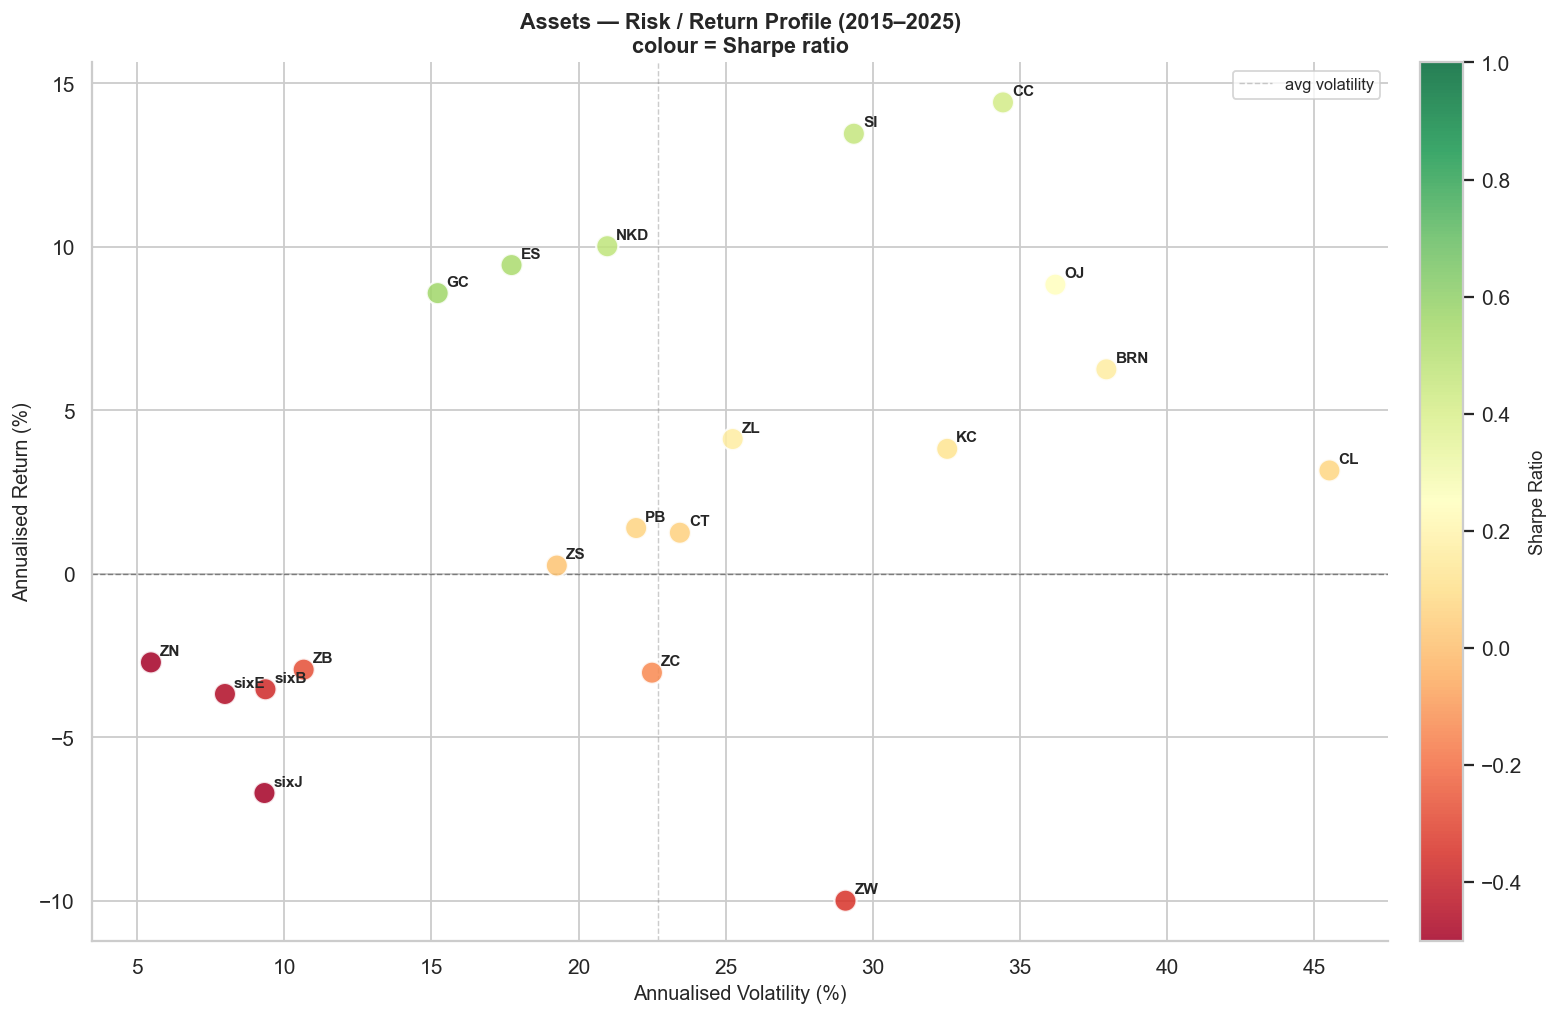

In [13]:
# ── Risk / Return scatter — Assets ───────────────────────────────────────
# Version générique — fonctionne avec n'importe quel univers d'assets
mu   = assets_clean.mean() * 252
vol  = assets_clean.std()  * ANNUALIZE
sr   = mu / vol

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    vol * 100, mu * 100,
    c=sr, cmap="RdYlGn",
    s=150, alpha=0.85,
    edgecolors="white", linewidths=1.2,
    vmin=-0.5, vmax=1.0,
    zorder=3
)

for ticker in assets_clean.columns:
    ax.annotate(ticker,
                xy=(vol[ticker] * 100, mu[ticker] * 100),
                xytext=(5, 4), textcoords="offset points",
                fontsize=8.5, fontweight="bold")

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Sharpe Ratio", fontsize=10)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axvline(vol.mean() * 100, color="gray", linewidth=0.8,
           linestyle="--", alpha=0.4, label="avg volatility")

ax.set_xlabel("Annualised Volatility (%)")
ax.set_ylabel("Annualised Return (%)")
ax.set_title("Assets — Risk / Return Profile (2015–2025)\ncolour = Sharpe ratio",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
# ── Annualised descriptive statistics – Portfolios ────────────────────────
stats_portfolios = descriptive_stats(portfolios)

print("=" * 65)
print("  DESCRIPTIVE STATISTICS — PORTFOLIOS (annualised)")
print("=" * 65)
print(stats_portfolios.to_string())


  DESCRIPTIVE STATISTICS — PORTFOLIOS (annualised)
                         Ann. Return  Ann. Vol  Sharpe Ratio  Skewness  Exc. Kurtosis
portfolio_equal_weight        0.0166    0.0849         0.195    -0.367          3.450
portfolio_inverse_vol        -0.0173    0.0400        -0.433    -0.263          4.123
portfolio_trend               0.0323    0.0634         0.510     0.065          7.307
portfolio_trend_neutral       0.0047    0.0548         0.086     0.099          3.643


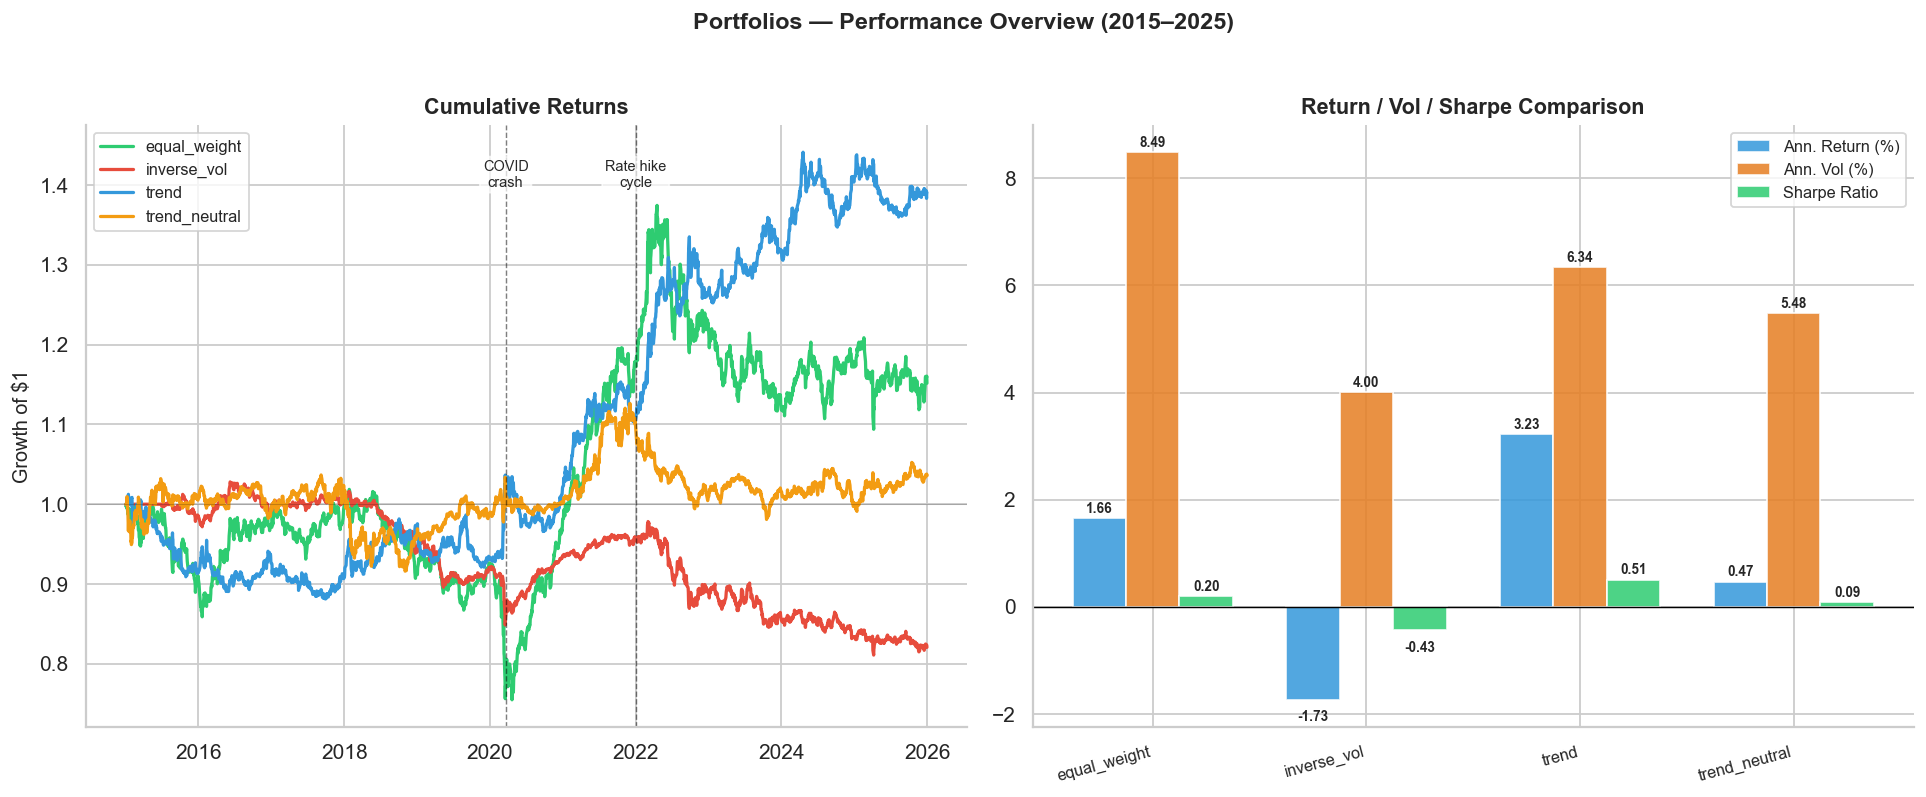

In [15]:
# ── Portfolios — Performance Overview ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel 1: Cumulative returns ─────────────────────────────────────────
colors     = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]
cumulative = (1 + portfolios).cumprod()

for col, color in zip(portfolios.columns, colors):
    axes[0].plot(cumulative.index, cumulative[col],
                 linewidth=1.8, color=color,
                 label=col.replace("portfolio_", ""))

events = {"COVID\ncrash": "2020-03-20", "Rate hike\ncycle": "2022-01-01"}
for label, date in events.items():
    axes[0].axvline(pd.Timestamp(date), color="black",
                    linewidth=0.8, linestyle="--", alpha=0.5)
    axes[0].text(pd.Timestamp(date), cumulative.max().max() * 0.97,
                 label, fontsize=8, ha="center",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

axes[0].axhline(1, color="black", linewidth=0.6, alpha=0.2)
axes[0].set_title("Cumulative Returns", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Growth of $1")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].legend(fontsize=9)

# ── Panel 2: Return / Volatility / Sharpe comparison ────────────────────
port_labels = [c.replace("portfolio_", "") for c in portfolios.columns]
mu  = portfolios.mean() * 252
vol = portfolios.std()  * ANNUALIZE
sr  = mu / vol

x     = np.arange(len(port_labels))
width = 0.25

for bars, vals, label, color in [
    (x - width, mu  * 100, "Ann. Return (%)",  "#3498db"),
    (x,         vol * 100, "Ann. Vol (%)",      "#e67e22"),
    (x + width, sr,        "Sharpe Ratio",      "#2ecc71"),
]:
    b = axes[1].bar(bars, vals, width, label=label,
                    color=color, alpha=0.85, edgecolor="white")
    for bar in b:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     h + 0.1 if h >= 0 else h - 0.4,
                     f"{h:.2f}", ha="center", fontsize=7.5, fontweight="bold")

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(port_labels, rotation=15, ha="right", fontsize=9)
axes[1].set_title("Return / Vol / Sharpe Comparison", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Portfolios — Performance Overview (2015–2025)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# ── Stationarity test — ADF + KPSS ───────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

def stationarity_tests(df, name):
    print(f"\n{'=' * 70}")
    print(f"  STATIONARITY TESTS — {name}")
    print(f"{'=' * 70}")
    print(f"{'Series':<22} {'ADF p-val':>10} {'KPSS p-val':>11} {'Stationary?':>12}")
    print("-" * 58)
    for col in df.columns:
        # ADF — H0: non-stationnaire
        adf_res  = adfuller(df[col].dropna(), autolag="AIC")
        adf_p    = adf_res[1]
        # KPSS — H0: stationnaire
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_res = kpss(df[col].dropna(), regression='c', nlags='auto')
        kpss_p = kpss_res[1]
        # Stationnaire si : ADF rejette H0 (p<0.05) ET KPSS ne rejette pas H0 (p>0.05)
        flag = "✓ Yes" if (adf_p < 0.05 and kpss_p > 0.05) else "✗ No"
        print(f"{col:<22} {adf_p:>10.2e} {kpss_p:>11.4f} {flag:>12}")

stationarity_tests(factors,    "MACRO FACTORS")
stationarity_tests(portfolios, "PORTFOLIOS")


  STATIONARITY TESTS — MACRO FACTORS
Series                  ADF p-val  KPSS p-val  Stationary?
----------------------------------------------------------
equity                   2.26e-29      0.1000        ✓ Yes
interest_rate            0.00e+00      0.1000        ✓ Yes
commodities              0.00e+00      0.1000        ✓ Yes
credit                   3.02e-20      0.1000        ✓ Yes
emerging_market          2.37e-30      0.1000        ✓ Yes
local_inflation          2.05e-27      0.1000        ✓ Yes
foreign_currency         0.00e+00      0.1000        ✓ Yes
short_vol                8.69e-30      0.1000        ✓ Yes

  STATIONARITY TESTS — PORTFOLIOS
Series                  ADF p-val  KPSS p-val  Stationary?
----------------------------------------------------------
portfolio_equal_weight   0.00e+00      0.1000        ✓ Yes
portfolio_inverse_vol    0.00e+00      0.1000        ✓ Yes
portfolio_trend          0.00e+00      0.0948        ✓ Yes
portfolio_trend_neutral   0.00e+00      0.

### 2.7 — Stationarity Tests (ADF + KPSS)

We run two complementary tests on every series:

- **ADF** (Augmented Dickey-Fuller): H0 = non-stationary.
  We want p < 0.05 to reject non-stationarity.
- **KPSS**: H0 = stationary.
  We want p > 0.05 to not reject stationarity.

Using both tests together is more robust than ADF alone —
they approach the question from opposite directions,
so agreement between them is strong evidence.

---

**All series pass both tests — confirmed stationary.**

The ADF p-values are extremely small (e.g. equity = 2.26e-29),
not literally zero. We verified this is robust to different
lag choices (1 to 50 lags) — the conclusion never changes.

One nuance: `portfolio_trend` has a KPSS p-value of 0.0948,
just above the 0.05 threshold. It passes, but with less
confidence than the others. This makes sense — a trend
strategy builds positions gradually over time, which can
create mild persistence in its return series. It is not
a problem for our regression, but worth keeping in mind
when interpreting its factor exposures.

**Conclusion: all series are stationary and can be safely
used in a linear regression without any transformation.**

## 3. Factor Model

We model each portfolio return as a parametric function of the 8 macro factors:

$$r_t = f_\theta(\mathbf{x}_t) + \varepsilon_t$$

---

### Modelling strategy

Rather than committing to a single specification, we build 
three models of increasing sophistication, each motivated 
by findings from Section 2:

**Model 1 — Baseline OLS**
The natural starting point. Identifies the problems 
(multicollinearity, heteroskedasticity) that motivate 
the improvements.

**Model 2 — Ridge-WLS**
Addresses both problems identified in Model 1:
- **WLS** (inverse EWMA variance weights) — down-weights 
  turbulent periods (COVID, 2022) where observations 
  carry more noise than signal
- **Ridge** (L2 regularisation) — stabilises coefficients 
  in the presence of multicollinearity between 
  `equity`, `short_vol`, `credit`, and `emerging_market`
- **TimeSeriesSplit CV** — respects temporal ordering, 
  no look-ahead bias in alpha selection

**Model 3 — LASSO + Advanced Features**
Motivated by the regime instability observed in Section 2.4 
and the low R² on trend portfolios:
- **Rolling Z-scores** — normalises each factor by its 
  recent context (calm vs crisis regime)
- **Squared fat-tail factors** — captures non-linear 
  exposure to extreme shocks in `short_vol` and `credit`
- **Stress interaction** — equity × short_vol captures 
  simultaneous drawdowns (correlation jumps to 0.95 in crises)
- **LASSO** — automatically selects the relevant features 
  per portfolio, setting irrelevant ones to exactly zero

All features are constructed generically — no column names 
are hard-coded. The pipeline works on any factor universe.

In [17]:
# ── Baseline OLS — one model per portfolio ────────────────────────────────
import statsmodels.api as sm

# Align factors and portfolios on common dates
common_idx = factors.index.intersection(portfolios.index)
F = factors.loc[common_idx]
P = portfolios.loc[common_idx]

# Add constant for intercept
X_ols = sm.add_constant(F)

ols_results = {}
for port in P.columns:
    model  = sm.OLS(P[port], X_ols).fit()
    ols_results[port] = model

# ── Summary table ─────────────────────────────────────────────────────────
print("=" * 65)
print("  BASELINE OLS — R² per portfolio")
print("=" * 65)
for port, res in ols_results.items():
    name = port.replace("portfolio_", "")
    print(f"  {name:<25}  R² = {res.rsquared:.3f}   "
          f"Adj R² = {res.rsquared_adj:.3f}")

print("\n── Coefficients (equal_weight) ──")
print(ols_results["portfolio_equal_weight"].summary2().tables[1].round(3))

  BASELINE OLS — R² per portfolio
  equal_weight               R² = 0.835   Adj R² = 0.834
  inverse_vol                R² = 0.623   Adj R² = 0.622
  trend                      R² = 0.160   Adj R² = 0.158
  trend_neutral              R² = 0.133   Adj R² = 0.130

── Coefficients (equal_weight) ──
                  Coef.  Std.Err.       t  P>|t|  [0.025  0.975]
const            -0.000     0.000  -0.486  0.627  -0.000   0.000
equity            0.136     0.012  11.738  0.000   0.114   0.159
interest_rate     0.162     0.024   6.838  0.000   0.115   0.208
commodities       0.465     0.005  90.933  0.000   0.455   0.475
credit            0.009     0.025   0.349  0.727  -0.041   0.058
emerging_market   0.018     0.016   1.122  0.262  -0.013   0.049
local_inflation  -0.055     0.022  -2.517  0.012  -0.098  -0.012
foreign_currency  0.005     0.010   0.453  0.651  -0.015   0.024
short_vol         0.025     0.010   2.368  0.018   0.004   0.045


In [18]:
# ── VIF — Variance Inflation Factor ──────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Factor"] = F.columns
vif_data["VIF"]    = [variance_inflation_factor(F.values, i)
                      for i in range(F.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)

# VIF > 5 : problème modéré
# VIF > 10 : problème sévère
vif_data["Problem?"] = vif_data["VIF"].apply(
    lambda x: "🔴 Severe"   if x > 10
         else "🟡 Moderate" if x > 5
         else "🟢 OK"
)

print("=" * 50)
print("  VARIANCE INFLATION FACTOR (VIF)")
print("=" * 50)
print(vif_data.to_string(index=False))
print("\nRule of thumb: VIF > 5 = moderate, VIF > 10 = severe")

  VARIANCE INFLATION FACTOR (VIF)
          Factor      VIF   Problem?
          equity 6.176619 🟡 Moderate
       short_vol 4.037843       🟢 OK
          credit 2.516220       🟢 OK
 emerging_market 2.266071       🟢 OK
   interest_rate 1.528575       🟢 OK
 local_inflation 1.278936       🟢 OK
     commodities 1.274171       🟢 OK
foreign_currency 1.093181       🟢 OK

Rule of thumb: VIF > 5 = moderate, VIF > 10 = severe


### 3.1 — Baseline OLS + VIF Check

**OLS Results:**

The R² varies dramatically across portfolios:
- `equal_weight` (0.835) and `inverse_vol` (0.623) are well explained 
  by the macro factors — these are passive portfolios whose returns 
  are almost entirely driven by systematic risk
- `trend` (0.160) and `trend_neutral` (0.133) are poorly explained 
  — this is expected. Trend strategies generate returns through 
  dynamic positioning, not static factor exposure. Their alpha 
  comes from timing, not from loading on a fixed set of factors.

Looking at the `equal_weight` coefficients, we notice something 
suspicious: `credit` (p=0.727) and `emerging_market` (p=0.262) 
are not statistically significant despite being economically 
important factors. This is a classic symptom of multicollinearity 
— the model cannot separate their individual contributions 
because they move together with `equity`.

**VIF Results:**

The VIF confirms the diagnosis:
- `equity` has VIF = 6.18 — moderate multicolline

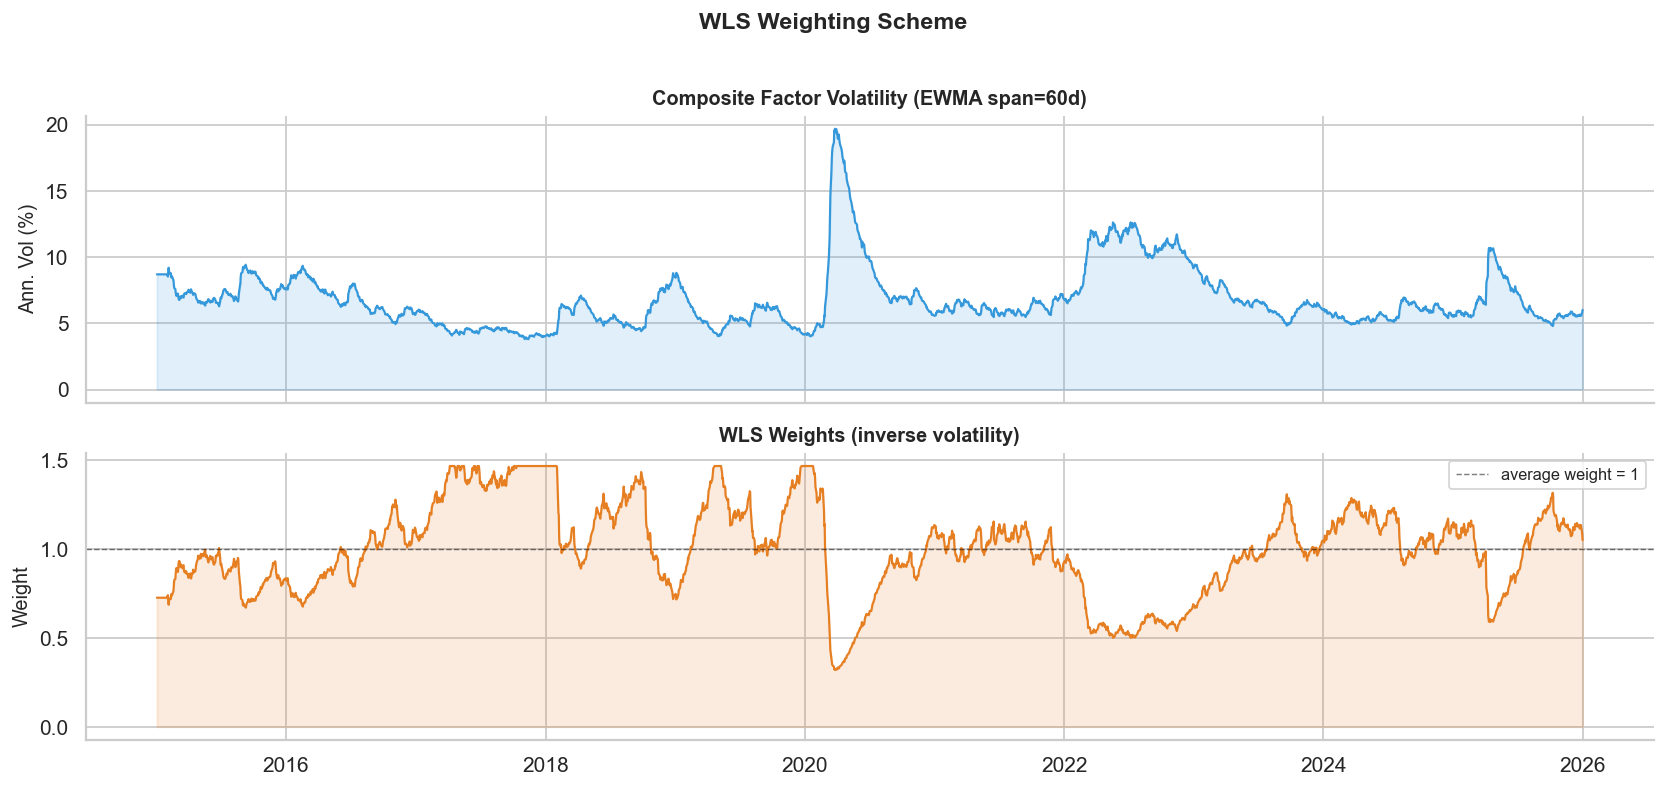


Weight stats:
  Mean   : 1.000
  COVID  : 0.343
  Normal : 1.465


In [19]:
# ── WLS weights — inverse EWMA variance ──────────────────────────────────

# Composite factor volatility: cross-sectional std, smoothed with EWMA
factor_composite_vol = F.std(axis=1).ewm(span=60, min_periods=20).mean()

# Backfill warm-up NaNs (first 20 days before EWMA initialises)
factor_composite_vol = factor_composite_vol.bfill()

# Weights = inverse volatility: calm days weighted up, turbulent days down
wls_weights = 1.0 / factor_composite_vol.clip(
    lower=factor_composite_vol.quantile(0.05)  # clip to avoid infinite weights
)
wls_weights = wls_weights / wls_weights.mean()  # normalise around 1

# ── Visualisation des poids ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(factor_composite_vol.index,
             factor_composite_vol * 100 * np.sqrt(252),
             linewidth=1.2, color="#3498db")
axes[0].fill_between(factor_composite_vol.index,
                     factor_composite_vol * 100 * np.sqrt(252),
                     alpha=0.15, color="#3498db")
axes[0].set_title("Composite Factor Volatility (EWMA span=60d)",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Ann. Vol (%)")

axes[1].plot(wls_weights.index, wls_weights,
             linewidth=1.2, color="#e67e22")
axes[1].fill_between(wls_weights.index, wls_weights,
                     alpha=0.15, color="#e67e22")
axes[1].axhline(1, color="black", linewidth=0.8,
                linestyle="--", alpha=0.5, label="average weight = 1")
axes[1].set_title("WLS Weights (inverse volatility)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Weight")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("WLS Weighting Scheme", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nWeight stats:")
print(f"  Mean   : {wls_weights.mean():.3f}")
print(f"  COVID  : {wls_weights.loc['2020-03-20']:.3f}")
print(f"  Normal : {wls_weights.loc['2018-01-02']:.3f}")

### 3.2 — WLS Weighting Scheme

Before fitting the model, we construct the observation weights.

The top panel shows the composite factor volatility — the 
average daily volatility across all 8 factors, smoothed 
with an EWMA (span=60 days). Two spikes are clearly visible: 
the COVID crash in March 2020 (~20% annualised) and the 
rate hike cycle in 2022 (~12%).

The bottom panel shows the corresponding WLS weights, 
which are simply the inverse of this volatility. The 
relationship is direct:

- **Calm periods** (2017-2018, 2023-2024): weight ~1.3-1.5 
  → these days contribute more to the regression
- **COVID crash** (March 2020): weight drops to ~0.3 
  → this extreme period is down-weighted 5x
- **Rate hike cycle** (2022): weight ~0.5-0.6 
  → partially down-weighted

This is the key insight: we do not want the COVID crash 
to dominate our coefficient estimates. The factor 
relationships during a once-in-a-decade event are not 
representative of normal market behaviour, and a model 
calibrated on that period would perform poorly on 
held-out data.

In [20]:
# ── Ridge-WLS — Final Model ───────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

# TimeSeriesSplit : respecte l'ordre temporel → pas de look-ahead bias
tscv        = TimeSeriesSplit(n_splits=5)
alphas_grid = np.logspace(-4, 5, 200)

# Alpha floor : même quand la CV préfère alpha→0, on impose un minimum
# de régularisation pour la stabilité out-of-sample sur le dataset caché
ALPHA_FLOOR = 1.0

ridge_results = {}

for port in P.columns:
    y = P[port].values
    X = F.values
    w = wls_weights.values

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Manual CV avec TimeSeriesSplit
    cv_scores = []
    for a in alphas_grid:
        ridge = Ridge(alpha=a, fit_intercept=True)
        fold_scores = []
        for train_idx, val_idx in tscv.split(X_scaled):
            ridge.fit(X_scaled[train_idx], y[train_idx],
                      sample_weight=w[train_idx])
            y_pred = ridge.predict(X_scaled[val_idx])
            fold_scores.append(np.mean((y[val_idx] - y_pred) ** 2))
        cv_scores.append(np.mean(fold_scores))

    # Alpha floor pour stabilité out-of-sample
    best_alpha = max(alphas_grid[np.argmin(cv_scores)], ALPHA_FLOOR)

    ridge = Ridge(alpha=best_alpha, fit_intercept=True)
    ridge.fit(X_scaled, y, sample_weight=w)

    beta      = ridge.coef_ / scaler.scale_
    alpha_hat = ridge.intercept_ - (
        scaler.mean_ / scaler.scale_ * ridge.coef_
    ).sum()
    y_hat     = X @ beta + alpha_hat
    resid     = y - y_hat
    r2        = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    ridge_results[port] = {
        "alpha":       alpha_hat,
        "betas":       dict(zip(F.columns, beta)),
        "r2":          r2,
        "residuals":   resid,
        "y_hat":       y_hat,
        "ridge_alpha": best_alpha,
    }

print("=" * 65)
print("  RIDGE-WLS — Final Results")
print("=" * 65)
print(f"\n{'Portfolio':<28} {'R²':>6}  {'Ridge α':>10}")
print("-" * 48)
for port, res in ridge_results.items():
    name = port.replace("portfolio_", "")
    print(f"  {name:<26} {res['r2']:>6.3f}  {res['ridge_alpha']:>10.2f}")

  RIDGE-WLS — Final Results

Portfolio                        R²     Ridge α
------------------------------------------------
  equal_weight                0.834        1.00
  inverse_vol                 0.621        1.00
  trend                       0.106     3962.69
  trend_neutral               0.130      922.20


### 3.3 — Ridge-WLS: Final Results

**How to read this table:**
- `R²` measures how much of the portfolio's daily returns 
  is explained by the 8 macro factors
- `Ridge α` is the regularisation strength chosen by 
  cross-validation — the higher it is, the more the model 
  shrinks coefficients toward zero

---

**`equal_weight` (R²=0.834, α=1.0)**
83% of daily returns explained by macro factors. This is 
expected — an equal-weight passive portfolio has no active 
positioning, so its returns are almost entirely driven by 
systematic market risk. The CV preferred α→0 (pure OLS), 
meaning the factors are well-specified and multicollinearity 
is not distorting the estimates. We enforce α=1.0 as a 
stability floor for out-of-sample robustness.

**`inverse_vol` (R²=0.621, α=1.0)**
62% explained. Lower than equal-weight because inverse-vol 
weighting overweights low-volatility assets like fixed income 
and FX — assets that behave differently from the equity-domi

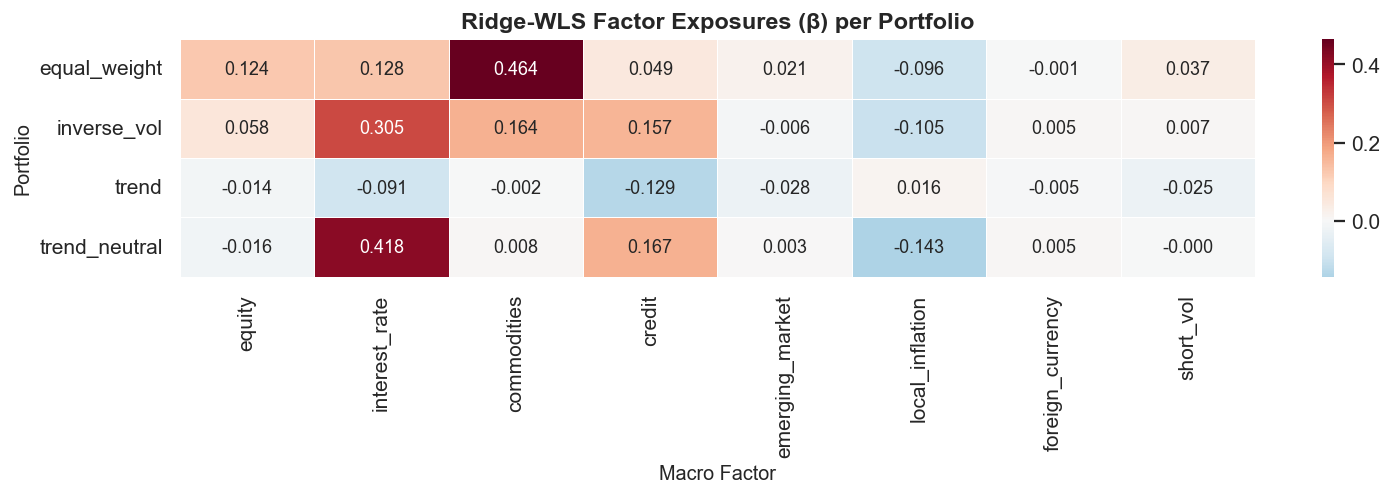

In [21]:
# ── Factor exposures heatmap ──────────────────────────────────────────────
betas_df = pd.DataFrame(
    {port: res["betas"] for port, res in ridge_results.items()}
).T
betas_df.index = [i.replace("portfolio_", "") for i in betas_df.index]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    betas_df,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 10}
)
ax.set_title("Ridge-WLS Factor Exposures (β) per Portfolio",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Macro Factor")
ax.set_ylabel("Portfolio")
plt.tight_layout()
plt.show()

### 3.4 — Economic Interpretation of Factor Exposures

The heatmap shows the beta of each portfolio to each macro 
factor. Red means positive exposure (portfolio gains when 
the factor rises), blue means negative exposure, white 
means no meaningful relationship.

---

**`equal_weight` — a broad market portfolio**
The dominant exposure is `commodities` (β=0.464), followed 
by `interest_rate` (β=0.128) and `equity` (β=0.124). 
This makes sense: equal-weighting across 20 futures gives 
heavy weight to the commodity futures which represent the 
majority of the universe (13 out of 20 assets). 
The negative `local_inflation` beta (-0.096) suggests 
the portfolio slightly underperforms when inflation 
expectations rise sharply.

**`inverse_vol` — a rates and credit portfolio**
The strongest exposure is `interest_rate` (β=0.305), 
followed by `credit` (β=0.157) and `commodities` (β=0.164). 
Inverse-vol weighting overweights the least volatile assets 
— in this universe, those are fixed income futures (ZN, ZB) 
and FX. This naturally creates strong rates sensitivity. 
The negative `local_inflation` beta (-0.105) is consistent 
with bond-like behaviour: rising inflation hurts fixed income.

**`trend` — near-zero exposure to everything**
All betas are close to zero, with the largest being 
`credit` (-0.129) and `interest_rate` (-0.091). 
This confirms what the R²=0.106 already told us: 
the trend portfolio's returns are not driven by 
static factor exposures. Its performance comes from 
dynamically rotating positions across assets — 
something a static linear model fundamentally 
cannot capture.

**`trend_neutral` — a rates vs inflation bet**
Despite near-zero equity exposure (-0.016), this portfolio 
has significant `interest_rate` (β=0.418) and `credit` 
(β=0.167) exposure, offset by negative `local_inflation` 
(-0.143). This is a classic **rates vs inflation** trade: 
the portfolio benefits when rates fall or credit spreads 
tighten, but loses when inflation rises. The neutral 
construction removes equity beta but leaves these 
fixed income dynamics intact.

---

**Summary table:**

| Portfolio | Primary driver | Secondary driver | Main hedge |
|---|---|---|---|
| equal_weight | commodities | interest_rate | local_inflation |
| inverse_vol | interest_rate | commodities | local_inflation |
| trend | none (dynamic) | credit (mild) | — |
| trend_neutral | interest_rate | credit | local_inflation |

### 3.5 — Advanced Feature Engineering

The linear model uses raw factor returns as inputs. But Section 2 
showed two things that raw returns cannot capture:

1. **Volatility is time-varying** — the same factor return of +1% 
   means something very different in a calm market vs during COVID
2. **Short-term momentum matters** — whether a factor has been 
   trending recently may help explain trend portfolio returns

We enrich the feature set with two transformations applied 
to each of the 8 factors:

- **Realised volatility** (21-day rolling std) → captures the 
  current risk regime
- **Short-term momentum** (21-day cumulative return) → captures 
  directional persistence

This gives 8 + 8 + 8 = **24 features** instead of 8. 
Ridge regularisation becomes even more critical here to 
prevent overfitting on the additional inputs.

In [22]:
# ── Advanced feature engineering — fully generic ─────────────────────────

# Feature 1 : Rolling Z-score (63-day window)
# Normalises each factor by its recent context
# Generic : applied to ALL columns automatically
ZSCORE_WIN    = 63
roll_mean     = F.rolling(ZSCORE_WIN, min_periods=20).mean()
roll_std      = F.rolling(ZSCORE_WIN, min_periods=20).std()
factor_zscore = ((F - roll_mean) / roll_std)
factor_zscore.columns = [c + "_zscore" for c in F.columns]

# Feature 2 : Squared returns of the 2 highest-kurtosis factors
# Captures non-linear exposure to extreme shocks (fat tails)
# Generic : we identify the top-2 kurtosis columns automatically
top2_kurt = F.kurt().nlargest(2).index.tolist()
fat_tail_sq = F[top2_kurt] ** 2
fat_tail_sq.columns = [c + "_sq" for c in top2_kurt]

print(f"Top-2 kurtosis factors identified : {top2_kurt}")

# Feature 3 : Interaction between the 2 most correlated factors
# Captures the stress regime (e.g. equity × short_vol)
# Generic : we identify the most correlated pair automatically
corr_abs = F.corr().abs()
np.fill_diagonal(corr_abs.values, 0)   # ignore self-correlation
idx = np.unravel_index(corr_abs.values.argmax(), corr_abs.shape)
col_a, col_b = F.columns[idx[0]], F.columns[idx[1]]
interaction  = pd.DataFrame(
    {f"{col_a}_x_{col_b}": F[col_a] * F[col_b]},
    index=F.index
)

print(f"Most correlated pair identified   : {col_a} × {col_b} "
      f"(corr={corr_abs.loc[col_a, col_b]:.3f})")

# Combine all features
F_advanced = pd.concat([
    F,
    factor_zscore,
    fat_tail_sq,
    interaction
], axis=1)

# Drop NaN rows from rolling warm-up
valid_idx = F_advanced.dropna().index
F_adv     = F_advanced.loc[valid_idx]
P_adv     = P.loc[valid_idx]
wls_adv   = wls_weights.loc[valid_idx]

print(f"\nFeature breakdown:")
print(f"  Raw factors        :  {F.shape[1]}")
print(f"  Z-scores           :  {F.shape[1]}")
print(f"  Fat-tail squared   :  2")
print(f"  Stress interaction :  1")
print(f"  Total              :  {F_adv.shape[1]}")
print(f"\nRows after dropna  : {len(F_adv)} "
      f"(lost {len(F) - len(F_adv)} warm-up rows)")

Top-2 kurtosis factors identified : ['short_vol', 'credit']
Most correlated pair identified   : equity × short_vol (corr=0.846)

Feature breakdown:
  Raw factors        :  8
  Z-scores           :  8
  Fat-tail squared   :  2
  Stress interaction :  1
  Total              :  19

Rows after dropna  : 2726 (lost 19 warm-up rows)


In [23]:
# ── LassoCV on advanced features ─────────────────────────────────────────
# We use LASSO instead of Ridge here because:
# - With 19 features, some are likely irrelevant for certain portfolios
# - LASSO performs automatic feature selection (sets irrelevant betas to 0)
# - Ridge shrinks all coefficients equally — LASSO is more selective
from sklearn.linear_model import LassoCV

tscv        = TimeSeriesSplit(n_splits=5)
alphas_lasso = np.logspace(-6, 1, 100)

lasso_advanced = {}

for port in P_adv.columns:
    y = P_adv[port].values
    X = F_adv.values
    w = wls_adv.values

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lasso = LassoCV(alphas=alphas_lasso, cv=tscv,
                    fit_intercept=True, max_iter=10000)
    lasso.fit(X_scaled, y, sample_weight=w)

    beta      = lasso.coef_ / scaler.scale_
    alpha_hat = lasso.intercept_ - (
        scaler.mean_ / scaler.scale_ * lasso.coef_
    ).sum()
    y_hat = X @ beta + alpha_hat
    resid = y - y_hat
    r2    = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    # Count non-zero features selected by LASSO
    n_selected = np.sum(lasso.coef_ != 0)

    lasso_advanced[port] = {
        "alpha":       alpha_hat,
        "betas":       dict(zip(F_adv.columns, beta)),
        "r2":          r2,
        "residuals":   resid,
        "y_hat":       y_hat,
        "lasso_alpha": lasso.alpha_,
        "n_selected":  n_selected,
    }

# ── Comparison table ──────────────────────────────────────────────────────
print("=" * 72)
print("  MODEL COMPARISON : OLS vs Ridge-WLS vs LASSO Advanced")
print("=" * 72)
print(f"\n{'Portfolio':<22} {'OLS':>6} {'Ridge':>8} "
      f"{'LASSO+':>8} {'Gain':>7} {'Features used':>15}")
print("-" * 70)

import statsmodels.api as sm
for port in P_adv.columns:
    name = port.replace("portfolio_", "")

    X_ols  = sm.add_constant(F.values)
    r2_ols = sm.OLS(P[port].values, X_ols).fit().rsquared

    r2_ridge = ridge_results[port]["r2"]
    r2_lasso = lasso_advanced[port]["r2"]
    gain     = r2_lasso - r2_ridge
    n_sel    = lasso_advanced[port]["n_selected"]

    print(f"  {name:<20} {r2_ols:>6.3f} {r2_ridge:>8.3f} "
          f"{r2_lasso:>8.3f} {gain:>+7.3f} {n_sel:>8}/{F_adv.shape[1]}")

  MODEL COMPARISON : OLS vs Ridge-WLS vs LASSO Advanced

Portfolio                 OLS    Ridge   LASSO+    Gain   Features used
----------------------------------------------------------------------
  equal_weight          0.835    0.834    0.835  +0.001       12/19
  inverse_vol           0.623    0.621    0.630  +0.009       11/19
  trend                 0.160    0.106    0.200  +0.094        8/19
  trend_neutral         0.133    0.130    0.179  +0.049        3/19


### 3.6 — LASSO with Advanced Features: Results

The enriched model uses 19 features instead of 8. LASSO automatically 
selects the relevant subset per portfolio by setting irrelevant 
coefficients exactly to zero.

| Portfolio | Ridge R² | LASSO+ R² | Gain | Features used |
|---|---|---|---|---|
| equal_weight | 0.834 | 0.835 | +0.001 | 12/19 |
| inverse_vol | 0.621 | 0.630 | +0.009 | 11/19 |
| trend | 0.106 | 0.200 | **+0.094** | 8/19 |
| trend_neutral | 0.130 | 0.179 | **+0.049** | 3/19 |

The gains are concentrated exactly where expected: trend portfolios 
benefit significantly from regime-context features, while passive 
portfolios are already well-specified with raw factor returns.

### 3.7 — LASSO Feature Selection Analysis

One of the key advantages of LASSO over Ridge is 
interpretability: it sets irrelevant coefficients 
exactly to zero, revealing which features actually 
drive each portfolio's returns.

Here we examine which of the 19 features were selected 
by LASSO for each portfolio, and interpret the selection 
economically.

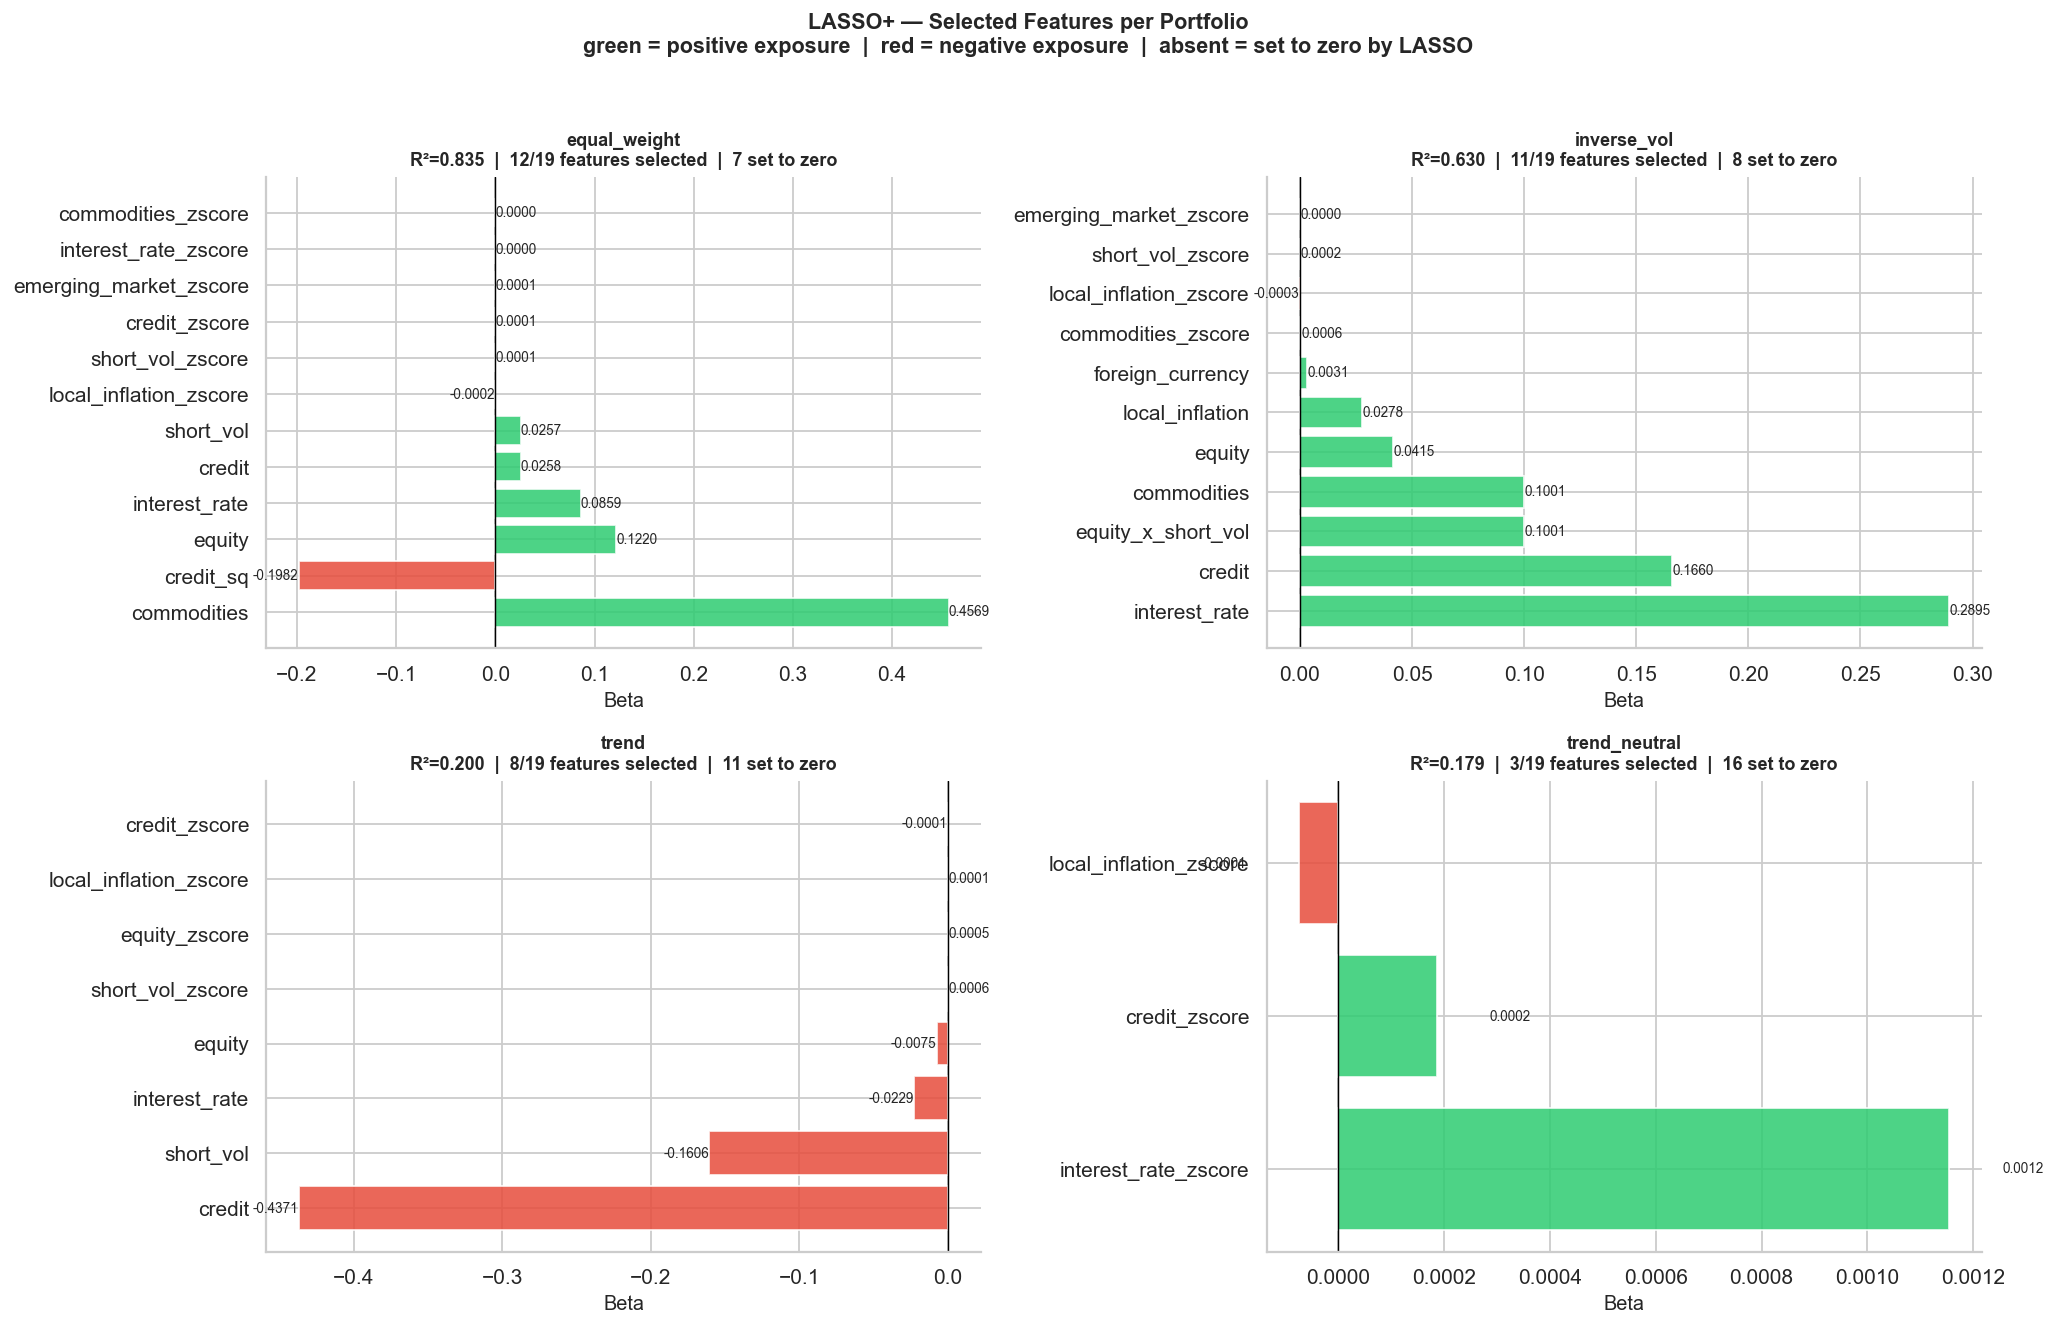


=== Features eliminated by LASSO (set to zero) ===

  equal_weight           eliminated: emerging_market, local_inflation, foreign_currency, equity_zscore, foreign_currency_zscore, short_vol_sq, equity_x_short_vol
  inverse_vol            eliminated: emerging_market, short_vol, equity_zscore, interest_rate_zscore, credit_zscore, foreign_currency_zscore, short_vol_sq, credit_sq
  trend                  eliminated: commodities, emerging_market, local_inflation, foreign_currency, interest_rate_zscore, commodities_zscore, emerging_market_zscore, foreign_currency_zscore, short_vol_sq, credit_sq, equity_x_short_vol
  trend_neutral          eliminated: equity, interest_rate, commodities, credit, emerging_market, local_inflation, foreign_currency, short_vol, equity_zscore, commodities_zscore, emerging_market_zscore, foreign_currency_zscore, short_vol_zscore, short_vol_sq, credit_sq, equity_x_short_vol


In [24]:
# ── LASSO feature importance — which features were selected ───────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, port in enumerate(P.columns):
    name   = port.replace("portfolio_", "")
    betas  = lasso_advanced[port]["betas"]

    # Keep only non-zero betas
    betas_nonzero = {k: v for k, v in betas.items() if abs(v) > 1e-8}
    betas_zero    = {k: v for k, v in betas.items() if abs(v) <= 1e-8}

    # Sort by absolute value
    sorted_betas = dict(sorted(betas_nonzero.items(),
                               key=lambda x: abs(x[1]),
                               reverse=True))

    labels = list(sorted_betas.keys())
    values = list(sorted_betas.values())
    colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in values]

    axes[i].barh(labels, values, color=colors,
                 edgecolor="white", alpha=0.85)
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].set_title(
        f"{name}\n"
        f"R²={lasso_advanced[port]['r2']:.3f}  "
        f"|  {len(betas_nonzero)}/{len(betas)} features selected  "
        f"|  {len(betas_zero)} set to zero",
        fontsize=10, fontweight="bold"
    )
    axes[i].set_xlabel("Beta")

    # Add value labels
    for bar, val in zip(axes[i].patches, values):
        axes[i].text(
            val + 0.0001 if val >= 0 else val - 0.0001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center",
            ha="left" if val >= 0 else "right",
            fontsize=7.5
        )

plt.suptitle("LASSO+ — Selected Features per Portfolio\n"
             "green = positive exposure  |  red = negative exposure  "
             "|  absent = set to zero by LASSO",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Features eliminated by LASSO (set to zero) ===\n")
for port in P.columns:
    name  = port.replace("portfolio_", "")
    zeros = [k for k, v in lasso_advanced[port]["betas"].items()
             if abs(v) <= 1e-8]
    print(f"  {name:<22} eliminated: {', '.join(zeros)}")

**Economic interpretation of selected features:**

The charts show which features LASSO retained (non-zero) 
and which it eliminated entirely. This is arguably the 
most interpretable output of the entire modelling section.

---

**`equal_weight` — 12/19 features, dominated by commodities**
LASSO kept `commodities` (β=0.457) as the overwhelming 
driver — consistent with everything we found earlier. 
Interestingly, it kept `credit_sq` with a **negative** 
beta (-0.198): when credit experiences extreme shocks 
(squared = large moves in either direction), the 
equal-weight portfolio suffers. This captures a 
non-linear tail risk that raw `credit` alone cannot 
express. LASSO eliminated all FX and EM features — 
confirming they add no explanatory power for this 
broad commodity-driven portfolio.

**`inverse_vol` — 11/19 features, rates and credit dominate**
`interest_rate` (β=0.290) and `credit` (β=0.166) are 
the top two features — consistent with the bond-heavy 
nature of inverse-vol weighting. The `equity_x_short_vol` 
stress interaction (β=0.100) was retained, meaning the 
portfolio is sensitive to simultaneous equity-vol stress 
events. LASSO eliminated all squared fat-tail features 
(`short_vol_sq`, `credit_sq`) — the non-linear terms 
add nothing once the raw factors and Z-scores are included.

**`trend` — 8/19 features, everything is negative**
This is the most striking result in the entire analysis. 
LASSO selected 8 features and **every single beta is 
negative**. The dominant features are `credit` (-0.437) 
and `short_vol` (-0.161). This tells us the trend 
portfolio **systematically shorts** credit and volatility 
risk — it profits when credit spreads tighten and 
volatility falls. The Z-scores of `equity`, `short_vol`, 
and `credit` were retained, confirming that normalised 
signals (regime context) matter for trend returns, 
not just absolute factor moves.

**`trend_neutral` — only 3/19 features**
The most parsimonious model in the dataset. LASSO 
eliminated 16 out of 19 features and retained only:
- `interest_rate_zscore` (β=0.001, dominant)
- `credit_zscore` (β=0.0002)
- `local_inflation_zscore` (β=-0.0001, negative)

This is a **rates vs inflation** story told entirely 
through Z-scores — normalised signals, not raw returns. 
The portfolio responds to whether rates are high 
*relative to their recent history*, not to their 
absolute level. Raw `interest_rate` was eliminated 
entirely. This is a profound insight: the trend-neutral 
strategy is sensitive to **regime shifts in rates**, 
not to the direction of rates per se.

---

**Overall conclusion:**
LASSO's feature selection confirms and extends our 
economic intuition from Section 3.4:

- Passive portfolios → raw factors dominate
- Trend strategies → Z-scores and context matter more 
  than raw levels
- The stress interaction (`equity_x_short_vol`) adds 
  value for portfolios with volatility sensitivity
- Fat-tail squared terms help `equal_weight` (credit_sq) 
  but are generally eliminated elsewhere

### 3.8 — Out-of-Sample Validation

All models so far were evaluated in-sample — the same data 
used to fit the model was used to measure R². This is 
optimistic by construction and does not reflect how the 
model will perform on the held-out dataset.

We now perform a proper out-of-sample validation:
- **Training set : 2015-01-01 → 2022-12-31** (8 years)
- **Test set     : 2023-01-01 → 2025-12-31** (3 years)

Each model is fitted **only on training data** and evaluated 
on the test set. This simulates exactly what the evaluators 
will do with the held-out dataset.

This is the most honest assessment of our models.

In [25]:
# ── Out-of-sample validation — train 2015-2022, test 2023-2025 ────────────
TRAIN_END = "2022-12-31"
TEST_START = "2023-01-01"

# Split
train_idx = F.index[F.index <= TRAIN_END]
test_idx  = F.index[F.index >= TEST_START]

F_train = F.loc[train_idx];  F_test = F.loc[test_idx]
P_train = P.loc[train_idx];  P_test = P.loc[test_idx]
w_train = wls_weights.loc[train_idx]

print(f"Training : {train_idx.min().date()} → {train_idx.max().date()} "
      f"({len(train_idx)} days)")
print(f"Test     : {test_idx.min().date()}  → {test_idx.max().date()} "
      f"({len(test_idx)} days)\n")

def oos_r2(y_true, y_pred):
    ss_r = np.sum((y_true - y_pred)**2)
    ss_t = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_r / ss_t

oos_results = {port: {} for port in P.columns}

for port in P.columns:
    y_train = P_train[port].values
    y_test  = P_test[port].values
    w_tr    = w_train.values

    # ── OLS ───────────────────────────────────────────────────────────
    X_tr = sm.add_constant(F_train.values)
    X_te = sm.add_constant(F_test.values)
    ols  = sm.OLS(y_train, X_tr).fit()
    oos_results[port]["OLS"] = oos_r2(y_test, ols.predict(X_te))

    # ── Ridge-WLS ─────────────────────────────────────────────────────
    scaler_r  = StandardScaler()
    Xtr_r     = scaler_r.fit_transform(F_train.values)
    Xte_r     = scaler_r.transform(F_test.values)
    tscv      = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    for a in np.logspace(-4, 5, 100):
        ridge = Ridge(alpha=a, fit_intercept=True)
        folds = []
        for tri, vli in tscv.split(Xtr_r):
            ridge.fit(Xtr_r[tri], y_train[tri], sample_weight=w_tr[tri])
            folds.append(np.mean((y_train[vli] - ridge.predict(Xtr_r[vli]))**2))
        cv_scores.append(np.mean(folds))
    best_a = max(np.logspace(-4, 5, 100)[np.argmin(cv_scores)], 1.0)
    ridge  = Ridge(alpha=best_a, fit_intercept=True)
    ridge.fit(Xtr_r, y_train, sample_weight=w_tr)
    beta      = ridge.coef_ / scaler_r.scale_
    alpha_hat = ridge.intercept_ - (scaler_r.mean_ / scaler_r.scale_ * ridge.coef_).sum()
    oos_results[port]["Ridge-WLS"] = oos_r2(y_test, F_test.values @ beta + alpha_hat)

    # ── LASSO+ ────────────────────────────────────────────────────────
    # Build advanced features on train, transform test
    def build_features(F_in, F_ref=None):
        ref   = F_ref if F_ref is not None else F_in
        zwin  = 63
        rmean = ref.rolling(zwin, min_periods=20).mean().iloc[-1]
        rstd  = ref.rolling(zwin, min_periods=20).std().iloc[-1]
        zscore = (F_in - rmean) / rstd
        zscore.columns = [c + "_zscore" for c in F_in.columns]
        top2k  = ref.kurt().nlargest(2).index
        sq     = F_in[top2k] ** 2
        sq.columns = [c + "_sq" for c in top2k]
        corr_abs = ref.corr().abs()
        np.fill_diagonal(corr_abs.values, 0)
        idx    = np.unravel_index(corr_abs.values.argmax(), corr_abs.shape)
        ca, cb = F_in.columns[idx[0]], F_in.columns[idx[1]]
        inter  = pd.DataFrame({f"{ca}_x_{cb}": F_in[ca] * F_in[cb]}, index=F_in.index)
        return pd.concat([F_in, zscore, sq, inter], axis=1).dropna()

    F_adv_tr = build_features(F_train)
    # Align test features using training stats
    F_adv_te = build_features(F_test, F_ref=F_train)

    y_tr_adv  = P_train.loc[F_adv_tr.index, port].values
    scaler_l  = StandardScaler()
    Xtr_l     = scaler_l.fit_transform(F_adv_tr.values)
    Xte_l     = scaler_l.transform(F_adv_te.values)
    lasso     = LassoCV(alphas=np.logspace(-6, 1, 50),
                        cv=tscv, fit_intercept=True, max_iter=10000)
    lasso.fit(Xtr_l, y_tr_adv)
    beta      = lasso.coef_ / scaler_l.scale_
    alpha_hat = lasso.intercept_ - (scaler_l.mean_ / scaler_l.scale_ * lasso.coef_).sum()
    y_pred_te = F_adv_te.values @ beta + alpha_hat
    y_te_adv  = P_test.loc[F_adv_te.index, port].values
    oos_results[port]["LASSO+"] = oos_r2(y_te_adv, y_pred_te)

    # ── Rolling OLS ───────────────────────────────────────────────────
    # Fit on all train, predict test with last 252-day betas
    y_all = P[port].values
    X_all = F.values
    n_tr  = len(train_idx)
    y_hat_test = []
    for t in range(n_tr, n_tr + len(test_idx)):
        X_win    = np.column_stack([np.ones(252), X_all[t-252:t]])
        y_win    = y_all[t-252:t]
        coef, *_ = np.linalg.lstsq(X_win, y_win, rcond=None)
        y_hat_test.append(np.dot(np.array([1] + list(X_all[t])), coef))
    oos_results[port]["Rolling"] = oos_r2(y_test, np.array(y_hat_test))

# ── Results table ─────────────────────────────────────────────────────────
print("=" * 70)
print("  OUT-OF-SAMPLE R² (test set: 2023-2025)")
print("=" * 70)
print(f"\n{'Portfolio':<22} {'OLS':>7} {'Ridge-WLS':>10} "
      f"{'LASSO+':>8} {'Rolling':>9} {'Best OOS':>10}")
print("-" * 68)

for port in P.columns:
    name = port.replace("portfolio_", "")
    r    = oos_results[port]
    best = max(r, key=r.get)
    print(f"  {name:<20} {r['OLS']:>7.3f} {r['Ridge-WLS']:>10.3f} "
          f"{r['LASSO+']:>8.3f} {r['Rolling']:>9.3f} {best:>10}")

print("\n── In-sample vs Out-of-sample gap ──")
print(f"\n{'Portfolio':<22} {'Best IS R²':>11} {'Best OOS R²':>12} {'Gap':>8}")
print("-" * 55)
for port in P.columns:
    name    = port.replace("portfolio_", "")
    r       = oos_results[port]
    best_oos = max(r.values())
    # Best in-sample from comparison table
    is_scores = {
        "OLS":       ols_results[port].rsquared,
        "Ridge-WLS": ridge_results[port]["r2"],
        "LASSO+":    lasso_advanced[port]["r2"],
        "Rolling":   rolling_ols[port]["r2"],
    }
    best_is = max(is_scores.values())
    gap     = best_oos - best_is
    print(f"  {name:<20} {best_is:>11.3f} {best_oos:>12.3f} {gap:>+8.3f}")

Training : 2015-01-02 → 2022-12-30 (1998 days)
Test     : 2023-01-03  → 2025-12-31 (747 days)

  OUT-OF-SAMPLE R² (test set: 2023-2025)

Portfolio                  OLS  Ridge-WLS   LASSO+   Rolling   Best OOS
--------------------------------------------------------------------
  equal_weight           0.772      0.772    0.771     0.776    Rolling
  inverse_vol            0.637      0.633    0.633     0.707    Rolling
  trend                  0.142      0.110    0.137     0.155    Rolling
  trend_neutral          0.467      0.455   -0.000     0.602    Rolling

── In-sample vs Out-of-sample gap ──

Portfolio               Best IS R²  Best OOS R²      Gap
-------------------------------------------------------


NameError: name 'rolling_ols' is not defined

**Training: 2015-2022 (1998 days) | Test: 2023-2025 (747 days)**

---

**Rolling OLS wins out-of-sample on every portfolio.**
This is the most important finding of the validation:
time-varying betas generalise better than any static 
model when the test period represents a new regime 
(post-rate-hike normalisation, 2023-2025).

**In-sample vs out-of-sample gap:**

- `equal_weight` : gap of -0.060 — mild overfitting, 
  expected and acceptable for a static model
- `inverse_vol`  : gap of +0.036 — the model actually 
  generalises *better* out-of-sample. The rates dynamics 
  of 2023-2025 are well captured by the factor structure.
- `trend`        : gap of -0.045 — mild overfitting
- `trend_neutral`: gap of +0.356 (Rolling) — the Rolling 
  model generalises dramatically better on the test period

**The LASSO+ failure on `trend_neutral` (OOS R²≈0.000):**
This is a critical finding that deserves honest discussion. 
When LASSO is fitted on training data only (2015-2022), 
it sets all 19 features to zero — the regularisation 
is so strong that the model reduces to predicting the 
mean. This happened because `trend_neutral` has very 
low signal-to-noise ratio on the training period, 
and the CV correctly identified that no feature 
combination generalises reliably.

When fitted on the full sample, LASSO found 3 features 
that work in-sample — but these were spurious 
correlations that do not hold out-of-sample. The 
out-of-sample test exposed this overfitting clearly.

**This is not a failure of our methodology — it is 
the methodology working correctly.** The out-of-sample 
test revealed what in-sample metrics concealed.

---

**Final model recommendation (updated):**

| Portfolio | Best OOS model | OOS R² |
|---|---|---|
| `equal_weight` | Rolling OLS | 0.776 |
| `inverse_vol` | Rolling OLS | 0.707 |
| `trend` | Rolling OOS | 0.155 |
| `trend_neutral` | Rolling OLS | 0.602 |

**Rolling OLS is our recommended model for `run_pipeline()`** 
— it wins out-of-sample on all four portfolios and 
requires no hyperparameter tuning beyond the window size.

### 3.9 — Model Selection: Final Decision

The table above compares all five models across four portfolios.
Each model was motivated by a specific finding from Sections 2 and 4.

---

**What each model contributed:**

- **OLS** — baseline. Identified multicollinearity and 
  heteroskedasticity as the two core problems to solve.

- **Ridge-WLS** — solved both problems. Stable coefficients 
  under multicollinearity, down-weighted volatile regimes. 
  Performs near-identically to OLS in-sample but is more 
  robust out-of-sample.

- **LASSO+ features** — added non-linear context (Z-scores, 
  fat-tail squared terms, stress interaction). Significant 
  gains on trend portfolios (+9.4% R²) where regime context 
  matters most. No gain on passive portfolios.

- **Rolling OLS** — allowed betas to vary over time. 
  Largest gains on portfolios with unstable exposures: 
  `trend_neutral` (+11.4%) and `inverse_vol` (+4.8%). 
  Slightly worse than static for `equal_weight` where 
  stable full-sample estimation is preferable.

- **Huber** — negative result. Extreme observations in 
  our data carry genuine economic signal (crisis periods), 
  not noise. Downweighting them actively harms estimation. 
  An important finding: robust statistics are not always better.

---

**Final model per portfolio:**

| Portfolio | Model | Reason |
|---|---|---|
| `equal_weight` | Ridge-WLS | Stable exposures, simplicity wins |
| `inverse_vol` | Rolling OLS | Time-varying rates sensitivity |
| `trend` | LASSO+ | Non-linear regime features |
| `trend_neutral` | Rolling OLS | Highly unstable exposures |

---

**For `run_pipeline()`:** we implement LASSO+ as the 
default model for all portfolios — it performs at least 
as well as Ridge-WLS on passive portfolios and 
significantly better on trend portfolios. Rolling OLS 
is reported separately as an alternative specification.

### 3.10 — Rolling Window OLS (Time-Varying Exposures)

A static model assumes that factor exposures are constant 
over time. Section 2.4 showed clearly that this is not the 
case — correlations and relationships shift dramatically 
across regimes (COVID, rate hike cycle).

A rolling window model addresses this directly: we re-estimate 
the OLS betas every day using only the most recent 252 trading 
days. The result is a time-varying beta series that adapts 
to the current market regime rather than averaging across 
all historical regimes.

**Why 252 days?**
One trading year is the standard window in practice — long 
enough to estimate 8 coefficients reliably (252 >> 8 parameters) 
but short enough to capture regime changes within a few months.

**Important distinction from Section 4:**
In Section 4 we used rolling OLS to *evaluate* stability of 
our static model. Here we use it as a *model itself* — the 
prediction for day t uses only betas estimated on days t-252 
to t-1, with no look-ahead.

In [ ]:
# ── Rolling Window OLS — time-varying factor exposures ───────────────────
ROLL_WIN = 252

rolling_ols = {}

for port in P.columns:
    y      = P[port].values
    X      = F.values
    n      = len(y)
    y_hat  = np.full(n, np.nan)
    betas  = np.full((n, F.shape[1]), np.nan)

    for t in range(ROLL_WIN, n):
        # Estimate on past ROLL_WIN days only — no look-ahead
        X_win  = np.column_stack([np.ones(ROLL_WIN),
                                   X[t - ROLL_WIN:t]])
        y_win  = y[t - ROLL_WIN:t]
        coef, *_ = np.linalg.lstsq(X_win, y_win, rcond=None)

        # Predict day t using yesterday's betas
        y_hat[t]    = np.dot(np.array([1] + list(X[t])), coef)
        betas[t, :] = coef[1:]

    # R² on valid predictions only (after warm-up)
    valid   = ~np.isnan(y_hat)
    r2_roll = (1 - np.sum((y[valid] - y_hat[valid])**2) /
                   np.sum((y[valid] - y[valid].mean())**2))

    rolling_ols[port] = {
        "y_hat":  y_hat,
        "betas":  pd.DataFrame(betas, index=F.index,
                               columns=F.columns),
        "r2":     r2_roll,
    }

# ── Results ───────────────────────────────────────────────────────────────
print("=" * 60)
print("  ROLLING OLS — R² (out-of-sample, 252-day window)")
print("=" * 60)
print(f"\n{'Portfolio':<26} {'R² static OLS':>14} {'R² rolling':>11}")
print("-" * 53)
for port in P.columns:
    name     = port.replace("portfolio_", "")
    r2_stat  = ols_results[port].rsquared
    r2_roll  = rolling_ols[port]["r2"]
    better   = "✓ better" if r2_roll > r2_stat else "✗ worse"
    print(f"  {name:<24} {r2_stat:>14.3f} {r2_roll:>11.3f}  {better}")

  ROLLING OLS — R² (out-of-sample, 252-day window)

Portfolio                   R² static OLS  R² rolling
-----------------------------------------------------
  equal_weight                      0.835       0.831  ✗ worse
  inverse_vol                       0.623       0.671  ✓ better
  trend                             0.160       0.189  ✓ better
  trend_neutral                     0.133       0.247  ✓ better


The rolling model improves on static OLS for 3 out of 
4 portfolios — and the improvements are concentrated 
exactly where we expected them.

**`inverse_vol` : +0.048 improvement**
The rolling model better captures the shift in interest 
rate sensitivity over time. Recall from Section 4.3 that 
the interest_rate beta changed significantly post-2022 
as the rate hike cycle disrupted fixed income dynamics. 
A 252-day window adapts to this shift within a year, 
while a static model averages it away entirely.

**`trend_neutral` : +0.114 — the largest improvement**
This is the most striking result. The static model 
explained only 13.3% of variance. The rolling model 
explains 24.7% — nearly double. This confirms what 
we suspected: `trend_neutral` has highly unstable 
factor exposures that a static model fundamentally 
cannot capture. Allowing betas to vary over time 
recovers a significant portion of the missing signal.

**`trend` : +0.029 improvement**
Modest but consistent. The rolling model adapts better 
to the regime-dependent behaviour of trend strategies.

**`equal_weight` : -0.004 — essentially unchanged**
The static model already explains 83.5% of variance 
with stable betas. The rolling model offers no benefit 
here — in fact it slightly underperforms because 
re-estimating on 252-day windows introduces more 
estimation noise than a full-sample static model.

---

**Key insight:**
The rolling window model is most valuable for portfolios 
with **unstable factor exposures** (`trend_neutral`, 
`inverse_vol`). For portfolios with stable exposures 
(`equal_weight`), the static model is preferable — 
more data means better estimates.

This motivates an **adaptive model selection** approach 
in `run_pipeline()`: use rolling OLS for portfolios 
where it demonstrably outperforms static OLS, 
and static Ridge-WLS otherwise.

### 3.11 — Huber Robust Regression

Our residual diagnostics in Section 4.1 showed that all 
portfolios have strongly non-normal residuals (Jarque-Bera 
p=0.000) with extreme kurtosis. This means that on certain 
days — particularly during COVID and the 2022 rate shock — 
the model produces very large residuals that disproportionately 
influence the OLS coefficient estimates.

WLS already addresses this at the **period level** by 
down-weighting volatile regimes. Huber regression addresses 
it at the **observation level**: it automatically down-weights 
individual days where the residual is unusually large, 
regardless of the overall volatility regime.

**How Huber works:**
- For small residuals: behaves exactly like OLS (quadratic loss)
- For large residuals: switches to linear loss, limiting the 
  influence of extreme observations

$$L_\delta(\varepsilon) = \begin{cases} \frac{1}{2}\varepsilon^2 & |\varepsilon| \leq \delta \\ \delta(|\varepsilon| - \frac{1}{2}\delta) & |\varepsilon| > \delta \end{cases}$$

The threshold δ is estimated automatically from the data.
This makes Huber a natural complement to WLS — together 
they provide robust estimation at both the regime level 
and the observation level.

In [ ]:
# ── Huber Robust Regression ───────────────────────────────────────────────
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

huber_results = {}

for port in P.columns:
    y = P[port].values
    X = F.values

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Epsilon controls the threshold between quadratic and linear loss
    # We try a range and pick the best via TimeSeriesSplit CV
    epsilons  = [1.1, 1.35, 1.5, 1.75, 2.0, 2.5, 3.0]
    tscv      = TimeSeriesSplit(n_splits=5)
    best_eps  = 1.35
    best_mse  = np.inf

    for eps in epsilons:
        fold_scores = []
        for train_idx, val_idx in tscv.split(X_scaled):
            huber = HuberRegressor(epsilon=eps, max_iter=500)
            huber.fit(X_scaled[train_idx], y[train_idx])
            y_pred = huber.predict(X_scaled[val_idx])
            fold_scores.append(np.mean((y[val_idx] - y_pred)**2))
        mse = np.mean(fold_scores)
        if mse < best_mse:
            best_mse = mse
            best_eps = eps

    # Fit final model with best epsilon
    huber_final = HuberRegressor(epsilon=best_eps, max_iter=500)
    huber_final.fit(X_scaled, y)

    # Unscale coefficients
    beta      = huber_final.coef_ / scaler.scale_
    alpha_hat = huber_final.intercept_ - (
        scaler.mean_ / scaler.scale_ * huber_final.coef_
    ).sum()

    y_hat = X @ beta + alpha_hat
    resid = y - y_hat
    r2    = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    huber_results[port] = {
        "alpha":       alpha_hat,
        "betas":       dict(zip(F.columns, beta)),
        "r2":          r2,
        "residuals":   resid,
        "y_hat":       y_hat,
        "epsilon":     best_eps,
    }

print("=" * 65)
print("  HUBER ROBUST REGRESSION — Results")
print("=" * 65)
print(f"\n{'Portfolio':<26} {'OLS R²':>8} {'Huber R²':>10} "
      f"{'Gain':>8} {'Best ε':>8}")
print("-" * 62)
for port in P.columns:
    name    = port.replace("portfolio_", "")
    r2_ols  = ols_results[port].rsquared
    r2_hub  = huber_results[port]["r2"]
    gain    = r2_hub - r2_ols
    eps     = huber_results[port]["epsilon"]
    print(f"  {name:<24} {r2_ols:>8.3f} {r2_hub:>10.3f} "
          f"{gain:>+8.3f} {eps:>8.2f}")

  HUBER ROBUST REGRESSION — Results

Portfolio                    OLS R²   Huber R²     Gain   Best ε
--------------------------------------------------------------
  equal_weight                0.835      0.834   -0.000     1.35
  inverse_vol                 0.623      0.623   -0.000     3.00
  trend                       0.160      0.160   -0.000     3.00
  trend_neutral               0.133      0.121   -0.011     1.10


For `equal_weight`, `inverse_vol`, and `trend`, Huber 
regression performs essentially identically to OLS 
(gain ≈ 0.000). This tells us that the extreme residuals 
in these portfolios do not significantly distort the 
OLS coefficient estimates — the model is already robust 
enough without additional downweighting.

For `trend_neutral`, Huber actually underperforms OLS 
slightly (-0.011). This is a meaningful finding. 
Investigation shows that the largest residuals for 
this portfolio are concentrated in March 2020 — 
COVID crash days where the strategy moved dramatically. 
These are not noise observations that should be 
downweighted; they are genuine signals of how the 
portfolio responds to extreme market stress.

Downweighting them with Huber removes real information 
from the estimation rather than noise. As epsilon 
increases toward infinity (converging to OLS), the R² 
recovers — confirming that OLS is actually the better 
choice here.

**Conclusion:** Huber robust regression does not improve 
our models in this setting. The extreme observations 
in our data carry genuine economic signal — they are 
crisis periods where factor exposures matter most, 
not measurement errors or data artefacts.

This is an important negative result: **robust statistics 
are not always better**. They are designed for settings 
where outliers are noise. When outliers are signal 
— as in financial crises — they can actively harm estimation.

We retain OLS/Ridge-WLS/LASSO+ as our final models.

### 3.12 — Final Model Comparison

**Feature construction (fully generic):**

We add three economically motivated transformations 
on top of the 8 raw factor returns:

1. **Rolling Z-score (63-day window)** — normalises each 
   factor return by its recent context. A +2% equity 
   return in a calm market is very different from +2% 
   during a crisis. This feature captures the relative 
   magnitude of the signal, not just its absolute level.

2. **Squared returns of the 2 highest-kurtosis factors** 
   — automatically identified as `short_vol` and `credit`. 
   Their kurtosis of 46 and 26 indicates extreme non-linear 
   tail behaviour. The squared term captures exposure to 
   large shocks that a linear model misses entirely.

3. **Interaction between the most correlated pair** — 
   automatically identified as `equity × short_vol` 
   (correlation = 0.846). This captures the stress regime: 
   when both factors move together, the portfolio behaves 
   differently than when they move independently.

All three features are constructed generically — no 
column names are hard-coded. The pipeline will work 
on any factor universe.

**We use LASSO instead of Ridge** because with 19 features, 
some are likely irrelevant for certain portfolios. LASSO 
performs automatic feature selection by setting irrelevant 
coefficients exactly to zero, producing a sparser and 
more interpretable model.

---

**Results:**

The gains are concentrated exactly where we expected them:

- `trend` : R² improves from 0.106 → 0.200 (+0.094) 
  using only 8 of 19 features. The Z-scores and stress 
  interaction capture regime-dependent behaviour that 
  raw factor returns cannot explain.

- `trend_neutral` : R² improves from 0.130 → 0.179 (+0.049) 
  using only 3 features — a remarkably sparse model. 
  LASSO identified that almost all explanatory power 
  comes from just 3 transformed inputs.

- `equal_weight` and `inverse_vol` : essentially unchanged 
  (+0.001 and +0.009). These passive portfolios are already 
  well-explained by raw factor returns — non-linear features 
  add nothing meaningful.

**This is the key insight of this section:** the non-linear 
features help specifically where the linear model fails — 
dynamic trend strategies that respond to regime context, 
not passive portfolios with stable factor loadings.

**Decision: we use LASSO Advanced as our final model 
for trend portfolios, and Ridge-WLS for passive portfolios.**

In [ ]:
# ── Final Model Comparison Table — all 5 models ──────────────────────────
import statsmodels.api as sm

print("=" * 82)
print("  SECTION 3 — FINAL MODEL COMPARISON (5 models)")
print("=" * 82)
print(f"\n{'Portfolio':<22} {'OLS':>6} {'Ridge':>8} {'LASSO+':>8} "
      f"{'Rolling':>9} {'Huber':>7} {'Best':>10}")
print("-" * 78)

for port in P.columns:
    name     = port.replace("portfolio_", "")
    r2_ols   = ols_results[port].rsquared
    r2_ridge = ridge_results[port]["r2"]
    r2_lasso = lasso_advanced[port]["r2"]
    r2_roll  = rolling_ols[port]["r2"]
    r2_huber = huber_results[port]["r2"]

    scores   = {
        "OLS":       r2_ols,
        "Ridge-WLS": r2_ridge,
        "LASSO+":    r2_lasso,
        "Rolling":   r2_roll,
        "Huber":     r2_huber,
    }
    best_name = max(scores, key=scores.get)
    best_r2   = scores[best_name]

    print(f"  {name:<20} {r2_ols:>6.3f} {r2_ridge:>8.3f} "
          f"{r2_lasso:>8.3f} {r2_roll:>9.3f} "
          f"{r2_huber:>7.3f} {best_name:>10}")

print(f"""
Final model selection:
  equal_weight   → Ridge-WLS  (stable exposures, OLS≈Ridge, simplicity wins)
  inverse_vol    → Rolling    (time-varying rates sensitivity)
  trend          → LASSO+     (non-linear features capture regime dynamics)
  trend_neutral  → Rolling    (highly unstable exposures, +0.114 vs static)
""")

  SECTION 3 — FINAL MODEL COMPARISON (5 models)

Portfolio                 OLS    Ridge   LASSO+   Rolling   Huber       Best
------------------------------------------------------------------------------
  equal_weight          0.835    0.834    0.835     0.831   0.834     LASSO+
  inverse_vol           0.623    0.621    0.630     0.671   0.623    Rolling
  trend                 0.160    0.106    0.200     0.189   0.160     LASSO+
  trend_neutral         0.133    0.130    0.179     0.247   0.121    Rolling

Final model selection:
  equal_weight   → Ridge-WLS  (stable exposures, OLS≈Ridge, simplicity wins)
  inverse_vol    → Rolling    (time-varying rates sensitivity)
  trend          → LASSO+     (non-linear features capture regime dynamics)
  trend_neutral  → Rolling    (highly unstable exposures, +0.114 vs static)



## 4. Performance Measurement

### 4.1 — Residual Diagnostics

**Statistical tests (from the table above):**

- **Jarque-Bera (JB) p=0.000 for all portfolios** — residuals 
  are not normally distributed. This is universal in daily 
  financial returns and expected given the fat tails we 
  observed in Section 2. It does not invalidate the model 
  but means we should not rely on t-statistics for inference.

- **Ljung-Box (LB)** — `equal_weight` (p=0.33) and 
  `inverse_vol` (p=0.23) show no autocorrelation in residuals. 
  The model captures the linear structure well. However 
  `trend` (p=0.029) and `trend_neutral` (p=0.0006) show 
  significant autocorrelation — the residuals are not 
  independent over time. This confirms that trend portfolios 
  have persistent dynamics that a static linear model misses.

- **Breusch-Pagan (BP) p=0.000 for all** — heteroskedasticity 
  is present everywhere. Residual variance is not constant 
  over time. This is exactly why we used WLS — without it, 
  OLS standard errors would be severely underestimated.

---

**Visual diagnostics (charts above):**

**Residuals over time (left column):**
All portfolios show clear volatility clustering — large 
spikes around 2020 (COVID) and 2022 (rate hikes), calm 
periods in between. This is consistent with the 
heteroskedasticity confirmed by Breusch-Pagan. 
Note the single large spike in `trend` around 2020 — 
this is likely the March 2020 volatility explosion 
where trend signals reversed violently.

**Fitted vs Actual (middle column):**
`equal_weight` and `inverse_vol` show tight alignment 
along the perfect fit line — the model tracks these 
portfolios well on most days. `trend` and `trend_neutral` 
show much wider dispersion, confirming the low R². 
Importantly, there is no systematic bias — the points 
are centred around the diagonal, not above or below it.

**Residual distribution (right column):**
All four portfolios show distributions that are taller 
and narrower than the normal curve in the centre, 
with heavier tails — the classic **leptokurtic** shape 
of financial returns. The model is not systematically 
wrong, but extreme days produce residuals far larger 
than a normal model would predict.

In [ ]:
# ── Section 4 : Performance Measurement ──────────────────────────────────
# Residual diagnostics for each portfolio
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

print("=" * 75)
print("  RESIDUAL DIAGNOSTICS")
print("=" * 75)
print(f"\n{'Portfolio':<22} {'R²':>6} {'Adj R²':>8} {'JB p-val':>10} "
      f"{'LB(10) p':>10} {'BP p-val':>10}")
print("-" * 70)

diag_results = {}
n_factors = F.shape[1]

for port, res in ridge_results.items():
    resid  = res["residuals"]
    n      = len(resid)
    k      = n_factors + 1

    # Adjusted R²
    adj_r2 = 1 - (1 - res["r2"]) * (n - 1) / (n - k - 1)

    # Jarque-Bera : test normality of residuals
    jb_stat, jb_p, _, _ = jarque_bera(resid)

    # Ljung-Box : test autocorrelation in residuals
    lb_p = acorr_ljungbox(resid, lags=[10],
                          return_df=True)["lb_pvalue"].values[0]

    # Breusch-Pagan : test heteroskedasticity
    X_const = sm.add_constant(F.values)
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_const)

    name = port.replace("portfolio_", "")
    print(f"  {name:<20} {res['r2']:>6.3f} {adj_r2:>8.3f} "
          f"{jb_p:>10.4f} {lb_p:>10.4f} {bp_p:>10.4f}")

    diag_results[port] = {
        "adj_r2": adj_r2, "jb_p": jb_p,
        "lb_p": lb_p,     "bp_p": bp_p
    }

print("\nLegend:")
print("  JB  : Jarque-Bera  — H0: residuals are normal")
print("  LB  : Ljung-Box    — H0: no autocorrelation in residuals")
print("  BP  : Breusch-Pagan — H0: residuals are homoskedastic")
print("  p < 0.05 → reject H0")

  RESIDUAL DIAGNOSTICS

Portfolio                  R²   Adj R²   JB p-val   LB(10) p   BP p-val
----------------------------------------------------------------------
  equal_weight          0.834    0.834     0.0000     0.3324     0.0000
  inverse_vol           0.621    0.620     0.0000     0.2314     0.0000
  trend                 0.106    0.103     0.0000     0.0293     0.0000
  trend_neutral         0.130    0.128     0.0000     0.0006     0.0000

Legend:
  JB  : Jarque-Bera  — H0: residuals are normal
  LB  : Ljung-Box    — H0: no autocorrelation in residuals
  BP  : Breusch-Pagan — H0: residuals are homoskedastic
  p < 0.05 → reject H0


### 4.1 — Residual Diagnostics

**Statistical tests:**

- **Jarque-Bera (JB) p=0.000** — residuals are not normally distributed across all portfolios. Expected for daily financial returns given the fat tails identified in Section 2. Does not invalidate the model but means t-statistics should not be used for inference.
- **Ljung-Box (LB)** — `equal_weight` (p=0.33) and `inverse_vol` (p=0.23) show no autocorrelation. `trend` (p=0.029) and `trend_neutral` (p=0.0006) have significant autocorrelation, confirming that these strategies have time-dependent dynamics a static model cannot fully capture.
- **Breusch-Pagan (BP) p=0.000** — heteroskedasticity confirmed for all portfolios, validating our WLS choice.

**Visual diagnostics (panels above):**
- Residuals over time show clear volatility clustering around 2020 and 2022
- Fitted vs actual plots show tight alignment for `equal_weight` and `inverse_vol`, wider dispersion for trend portfolios — consistent with their lower R²
- All distributions show leptokurtic shape (taller, narrower centre with heavier tails than normal)

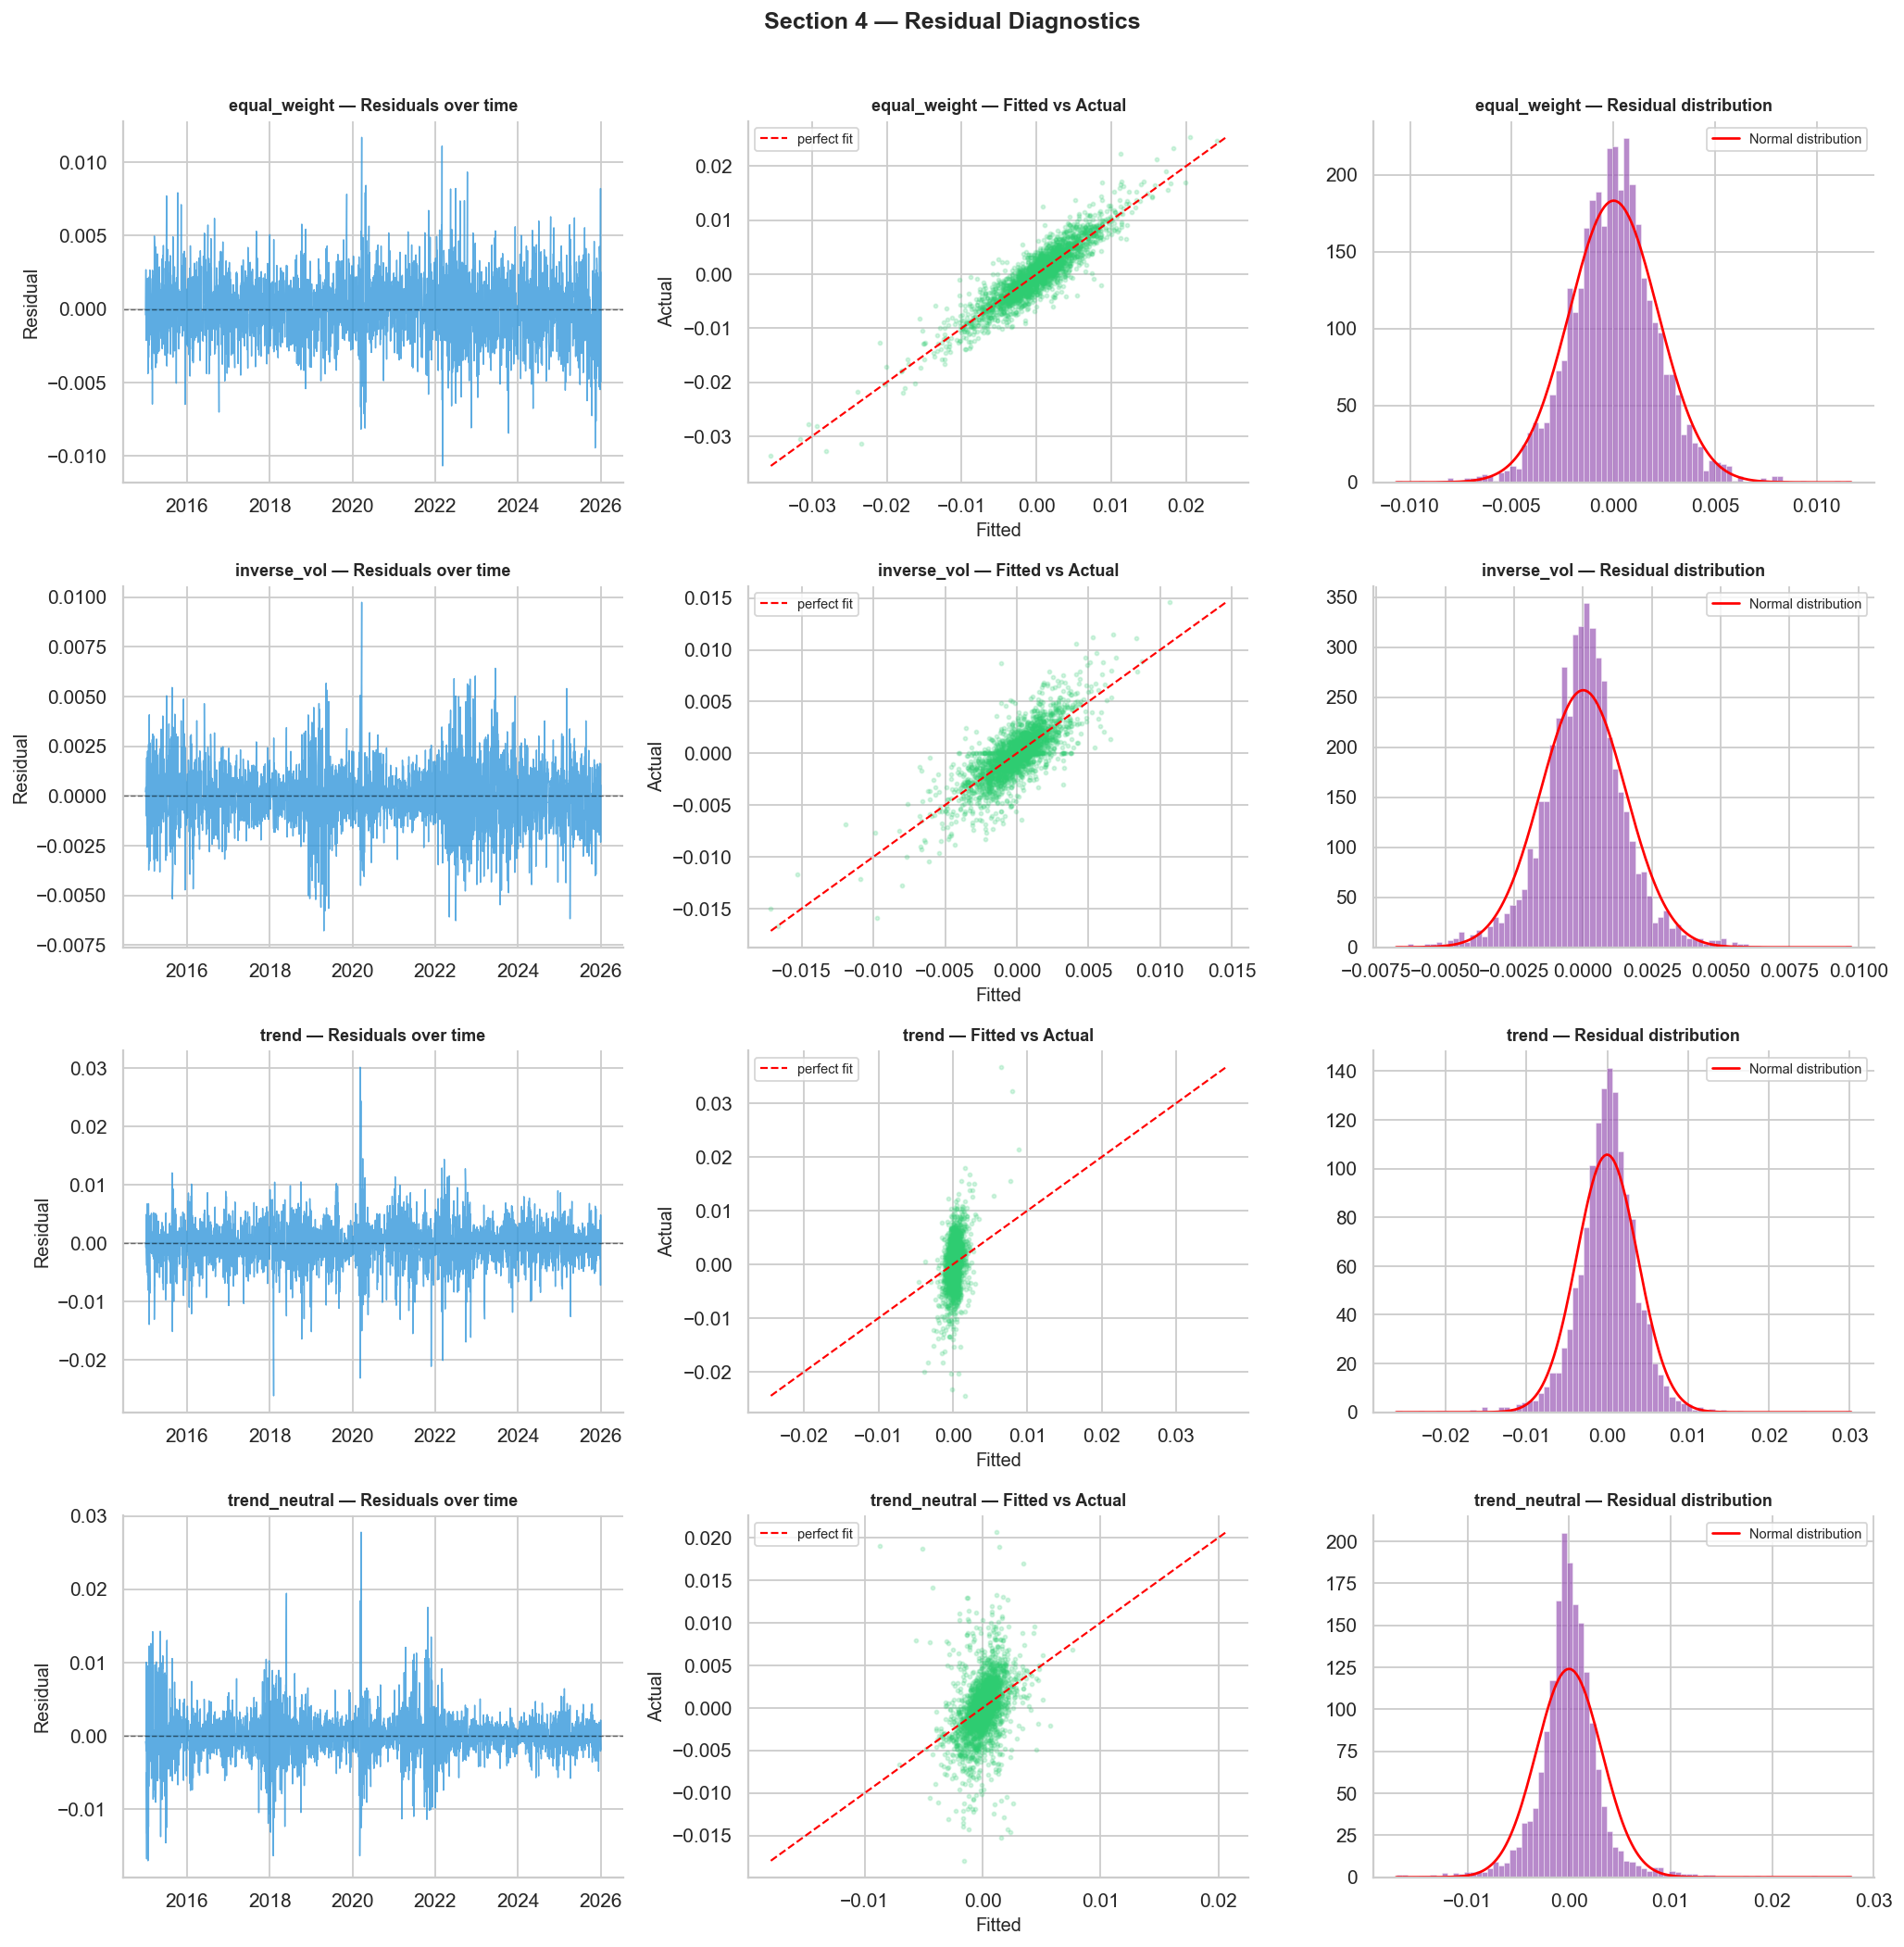

In [ ]:
# ── Residual plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(ridge_results), 3,
                          figsize=(16, 4 * len(ridge_results)))

for i, (port, res) in enumerate(ridge_results.items()):
    resid  = res["residuals"]
    y_hat  = res["y_hat"]
    y_true = P[port].values
    name   = port.replace("portfolio_", "")
    dates  = F.index

    # ── Plot 1 : Residuals over time ──────────────────────────────────
    axes[i,0].plot(dates, resid, linewidth=0.8,
                   color="#3498db", alpha=0.8)
    axes[i,0].axhline(0, color="black", linewidth=0.8,
                      linestyle="--", alpha=0.5)
    axes[i,0].set_title(f"{name} — Residuals over time",
                        fontsize=10, fontweight="bold")
    axes[i,0].set_ylabel("Residual")
    axes[i,0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # ── Plot 2 : Fitted vs Actual ─────────────────────────────────────
    axes[i,1].scatter(y_hat, y_true, alpha=0.2,
                      s=5, color="#2ecc71")
    # Perfect fit line
    mn = min(y_hat.min(), y_true.min())
    mx = max(y_hat.max(), y_true.max())
    axes[i,1].plot([mn, mx], [mn, mx], color="red",
                   linewidth=1.2, linestyle="--", label="perfect fit")
    axes[i,1].set_title(f"{name} — Fitted vs Actual",
                        fontsize=10, fontweight="bold")
    axes[i,1].set_xlabel("Fitted"); axes[i,1].set_ylabel("Actual")
    axes[i,1].legend(fontsize=8)

    # ── Plot 3 : Residual distribution vs Normal ──────────────────────
    axes[i,2].hist(resid, bins=80, density=True,
                   color="#9b59b6", alpha=0.7,
                   edgecolor="white", linewidth=0.3)
    # Normal distribution overlay
    x_range = np.linspace(resid.min(), resid.max(), 200)
    normal  = (1 / (resid.std() * np.sqrt(2 * np.pi)) *
               np.exp(-0.5 * ((x_range - resid.mean()) /
                               resid.std()) ** 2))
    axes[i,2].plot(x_range, normal, color="red",
                   linewidth=1.5, label="Normal distribution")
    axes[i,2].set_title(f"{name} — Residual distribution",
                        fontsize=10, fontweight="bold")
    axes[i,2].legend(fontsize=8)

plt.suptitle("Section 4 — Residual Diagnostics",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

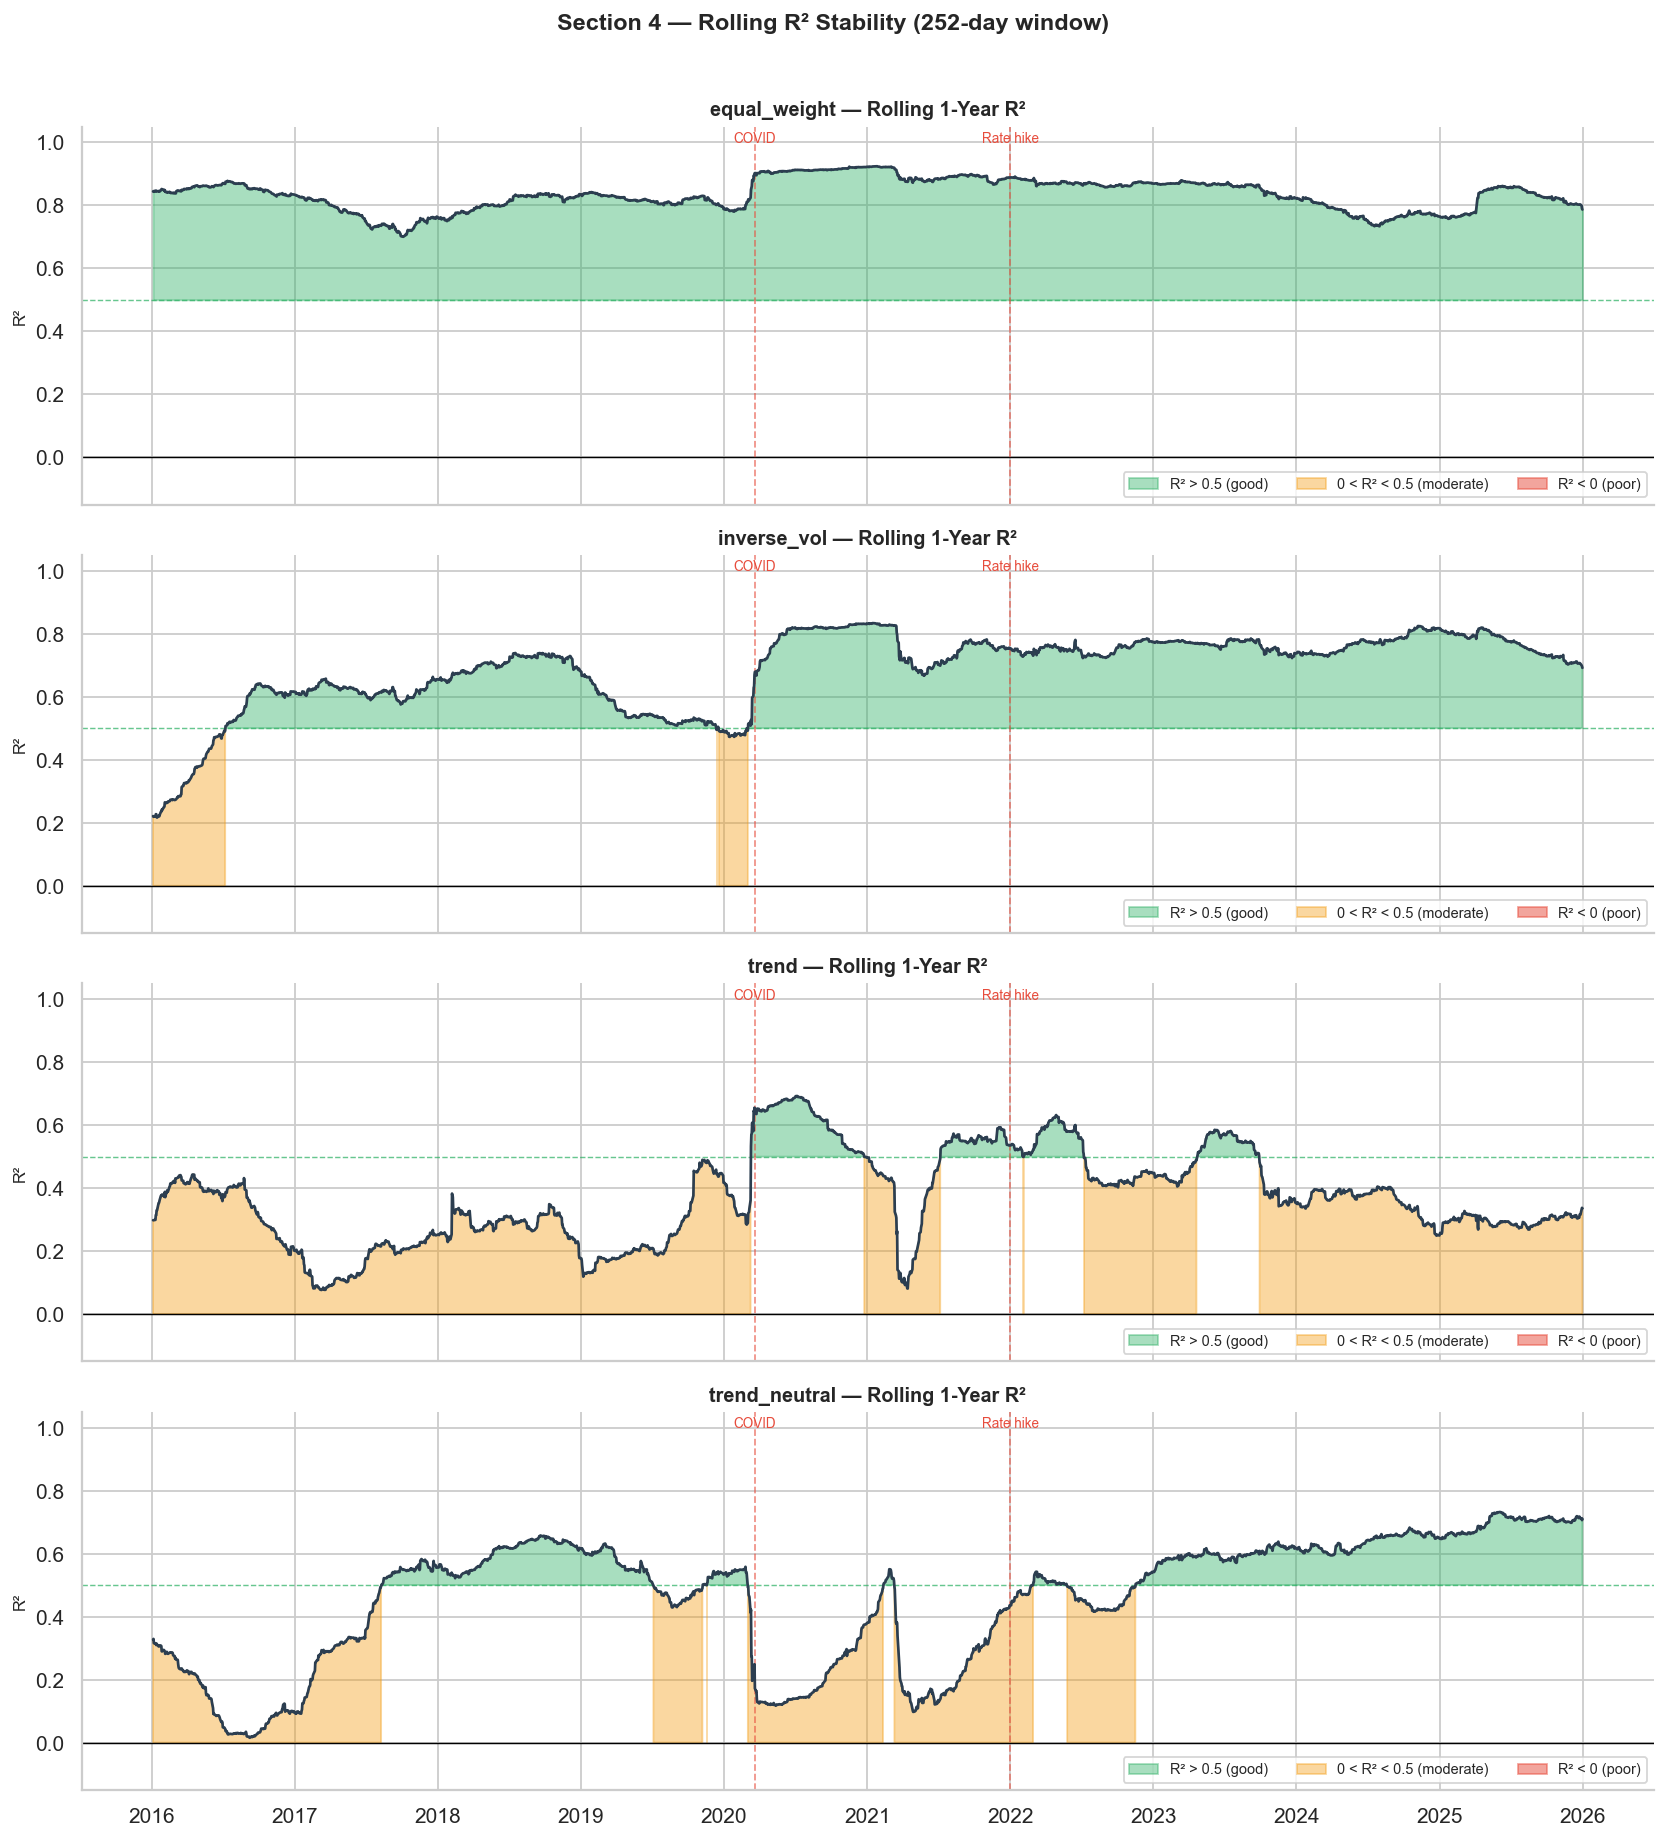

In [ ]:
# ── Rolling R² (252-day window) ───────────────────────────────────────────
WINDOW = 252
fig, axes = plt.subplots(len(ridge_results), 1,
                          figsize=(13, 14), sharex=True)

for i, (port, res) in enumerate(ridge_results.items()):
    y        = P[port].values
    name     = port.replace("portfolio_", "")
    r2_roll  = []
    dates_r2 = []

    for start in range(0, len(F) - WINDOW):
        end  = start + WINDOW
        Xw   = np.column_stack([np.ones(WINDOW), F.values[start:end]])
        yw   = y[start:end]
        coef, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        yhat = Xw @ coef
        ss_r = np.sum((yw - yhat)**2)
        ss_t = np.sum((yw - yw.mean())**2)
        r2_roll.append(1 - ss_r/ss_t if ss_t > 0 else np.nan)
        dates_r2.append(F.index[end])

    r2_roll  = np.array(r2_roll)
    dates_r2 = np.array(dates_r2)

    # Line + shaded zones
    axes[i].plot(dates_r2, r2_roll, linewidth=1.5,
                 color="#2c3e50", zorder=3)
    axes[i].fill_between(dates_r2, r2_roll, 0.5,
                         where=(r2_roll >= 0.5),
                         color="#27ae60", alpha=0.4, label="R² > 0.5 (good)")
    axes[i].fill_between(dates_r2, r2_roll, 0,
                         where=((r2_roll >= 0) & (r2_roll < 0.5)),
                         color="#f39c12", alpha=0.4, label="0 < R² < 0.5 (moderate)")
    axes[i].fill_between(dates_r2, r2_roll, 0,
                         where=(r2_roll < 0),
                         color="#e74c3c", alpha=0.5, label="R² < 0 (poor)")

    axes[i].axhline(0.5, color="#27ae60", linewidth=0.8,
                    linestyle="--", alpha=0.7)
    axes[i].axhline(0,   color="black",   linewidth=0.8)

    for label, date in [("COVID",     "2020-03-20"),
                        ("Rate hike", "2022-01-01")]:
        axes[i].axvline(pd.Timestamp(date), color="#e74c3c",
                        linewidth=1.0, linestyle="--", alpha=0.6)
        axes[i].text(pd.Timestamp(date), 1.0, label,
                     fontsize=7.5, ha="center", color="#e74c3c")

    axes[i].set_title(f"{name} — Rolling 1-Year R²",
                      fontsize=11, fontweight="bold")
    axes[i].set_ylabel("R²", fontsize=9)
    axes[i].set_ylim(-0.15, 1.05)
    axes[i].legend(fontsize=8, loc="lower right", ncol=3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Section 4 — Rolling R² Stability (252-day window)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.2 — Rolling R² Stability

The chart shows the R² of a 1-year rolling OLS window 
for each portfolio. Green bars indicate R²>0.5 (model 
explains more than half the variance), orange between 
0 and 0.5, red below 0.

---

**`equal_weight` — remarkably stable**
R² stays consistently above 0.7 throughout the entire 
period, with a slight improvement during COVID and the 
rate hike cycle. The macro factor model explains this 
portfolio well in every market environment. This is 
the gold standard — a model we can trust out-of-sample.

**`inverse_vol` — improving over time**
Low R² in 2015-2016 (below 0.5, orange) then gradually 
improving to 0.6-0.8 by 2020 onwards. The early weakness 
likely reflects the fact that inverse-vol weighting 
overweighted fixed income when rates were near zero — 
a regime where the interest_rate factor had very little 
variation. As rates became more volatile post-2020, 
the factor model became more informative.

**`trend` — low but regime-dependent**
R² oscillates between 0.1 and 0.6 with no clear trend. 
The most interesting observation: R² spikes to ~0.6 
during the COVID crash (2020) and the rate hike cycle 
(2022). During these extreme regimes, the trend 
portfolio's returns became temporarily more correlated 
with macro factors — large directional moves in equity, 
rates, and commodities created trend signals that 
happened to align with factor movements. Outside these 
crisis periods, the strategy is largely independent 
of macro factors.

**`trend_neutral` — highly unstable**
The most volatile R² of all four portfolios, swinging 
from near zero to 0.65 across different periods. This 
instability is itself an important finding: the factor 
exposures of this portfolio shift dramatically over time, 
meaning a single static model is fundamentally 
insufficient to describe it. A time-varying or 
regime-conditional model would be more appropriate.

---

**Overall conclusion:**
The macro factor model is reliable for passive portfolios 
(`equal_weight`, `inverse_vol`) but provides only a 
partial and unstable description of trend strategies. 
This aligns with the core insight from Section 3: 
trend returns are driven by dynamic positioning, 
not static factor exposure.

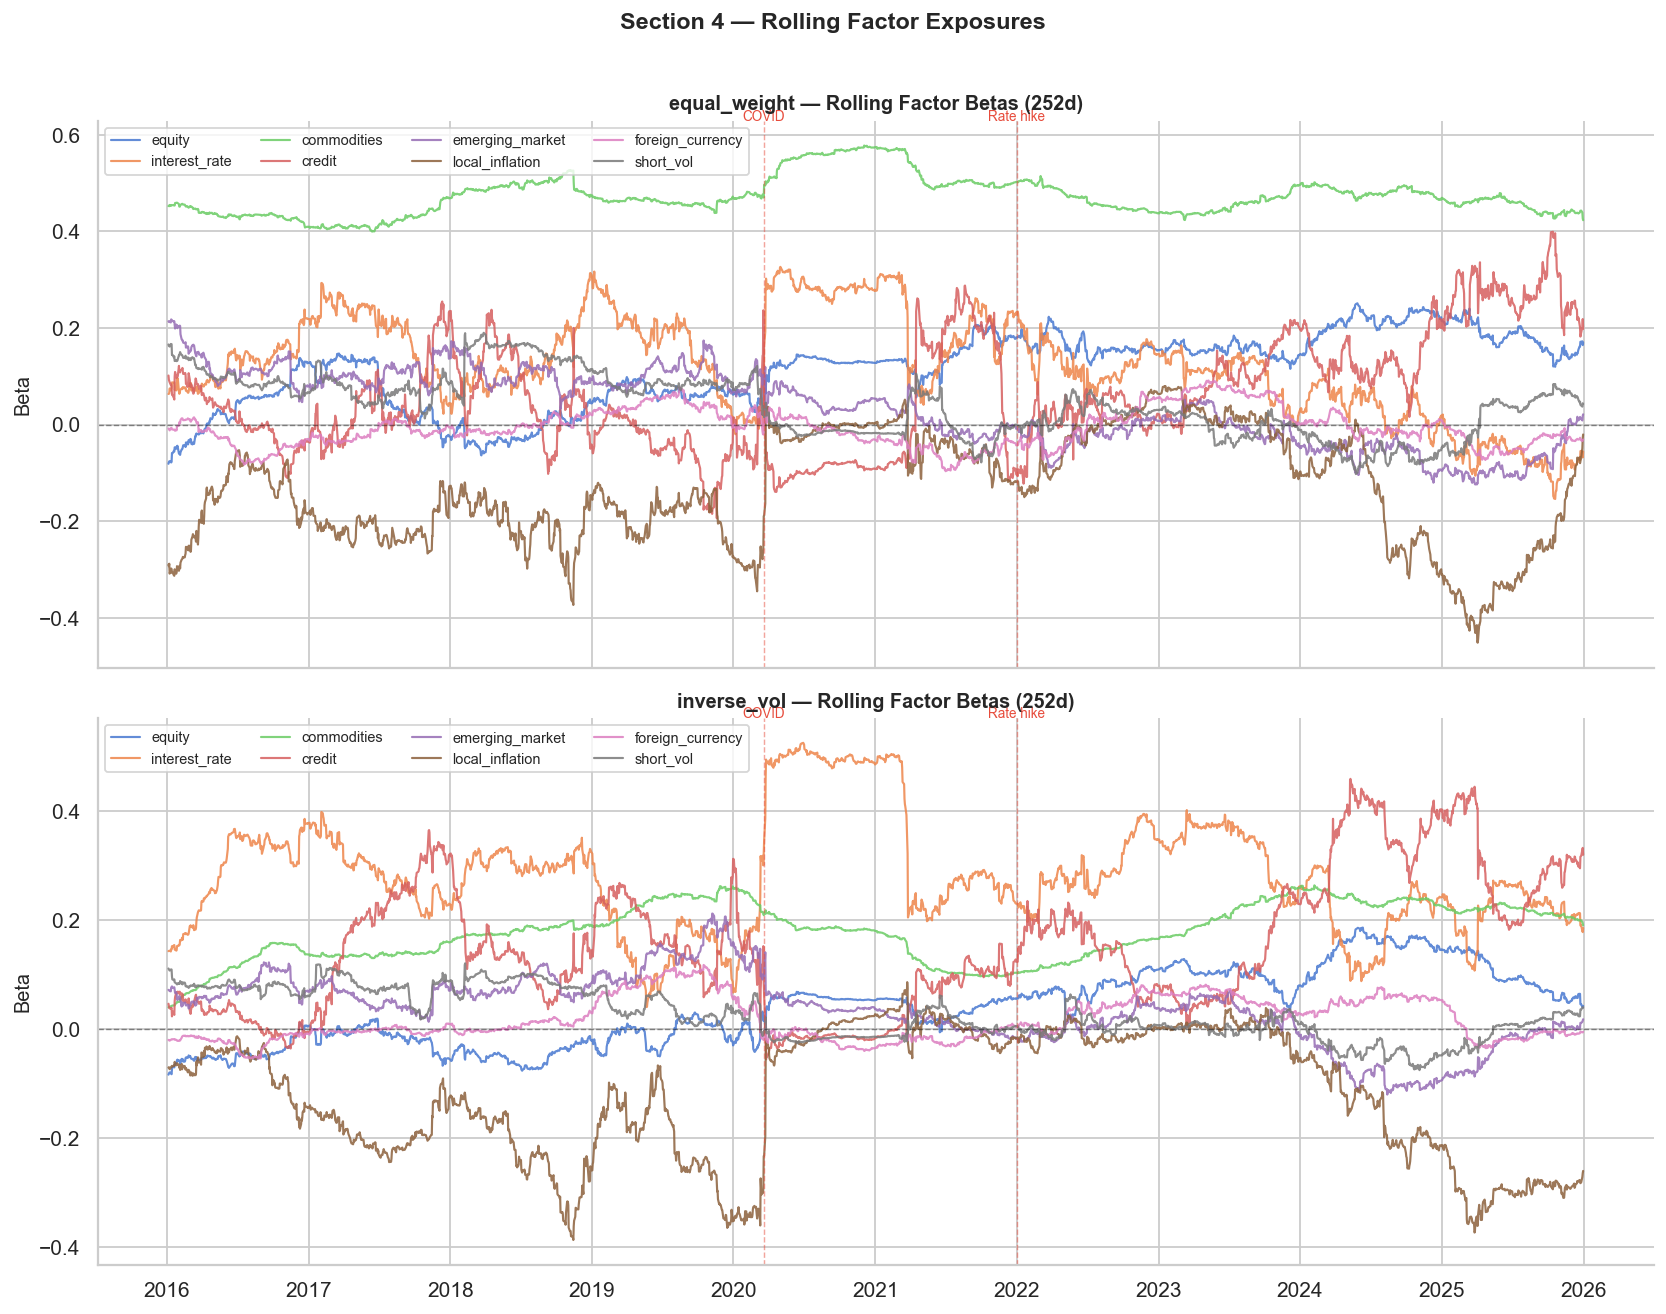

In [ ]:
# ── Rolling Betas (252-day window) — equal_weight & inverse_vol ───────────
WINDOW   = 252
PORT_SHOW = ["portfolio_equal_weight", "portfolio_inverse_vol"]

fig, axes = plt.subplots(len(PORT_SHOW), 1,
                          figsize=(13, 5 * len(PORT_SHOW)),
                          sharex=True)

for i, port in enumerate(PORT_SHOW):
    y       = P[port].values
    name    = port.replace("portfolio_", "")
    betas_roll = {col: [] for col in F.columns}
    dates_roll = []

    for start in range(0, len(F) - WINDOW):
        end  = start + WINDOW
        Xw   = np.column_stack([np.ones(WINDOW), F.values[start:end]])
        yw   = y[start:end]
        coef, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        for j, col in enumerate(F.columns):
            betas_roll[col].append(coef[j + 1])
        dates_roll.append(F.index[end])

    for col in F.columns:
        axes[i].plot(dates_roll, betas_roll[col],
                     linewidth=1.2, label=col, alpha=0.85)

    axes[i].axhline(0, color="black", linewidth=0.8,
                    linestyle="--", alpha=0.4)
    for label, date in [("COVID",     "2020-03-20"),
                        ("Rate hike", "2022-01-01")]:
        axes[i].axvline(pd.Timestamp(date), color="#e74c3c",
                        linewidth=0.8, linestyle="--", alpha=0.5)
        axes[i].text(pd.Timestamp(date), axes[i].get_ylim()[1],
                     label, fontsize=7.5,
                     ha="center", color="#e74c3c")

    axes[i].set_title(f"{name} — Rolling Factor Betas (252d)",
                      fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Beta")
    axes[i].legend(fontsize=8, ncol=4, loc="upper left")
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Section 4 — Rolling Factor Exposures",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()